In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



import math
import pickle

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [2]:
# df = pd.read_csv("E:\Document\PROJECT\data\processed\data2225_done.csv")
# df = pd.read_csv("data/processed/data2225_done.csv")


df = pd.read_csv('/content/data2225_done.csv')
df.head()

,Local Time,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,IsHoliday,Accumulated Hours of Rain
0,2022-01-13 07:00:00,353.1,10.0,84.0,98.0,17.08,52.0,100,0.00,1020,95.0,15.5,0.6,2.00,False,0
1,2022-01-13 08:00:00,343.5,9.0,87.3,95.7,16.75,48.7,91,0.00,1021,94.0,15.4,0.7,2.33,False,0
2,2022-01-13 09:00:00,334.0,8.0,90.7,93.3,16.42,45.3,83,0.50,1022,93.0,15.3,1.0,2.66,False,1
3,2022-01-13 10:00:00,324.5,7.0,94.0,91.0,16.09,42.0,75,0.75,1022,93.0,15.2,1.5,3.00,False,2
4,2022-01-13 11:00:00,319.6,6.7,95.7,91.3,16.17,39.0,83,0.00,1021,87.0,15.6,1.9,3.00,False,0


In [3]:
df['Local Time'] = pd.to_datetime(df['Local Time'])
df = df.set_index('Local Time').sort_index()

agg_map = {col: "mean" for col in df.columns}
if "IsHoliday" in agg_map:
    agg_map["IsHoliday"] = "max"

df = df.resample("3H").agg(agg_map).dropna().copy()

/tmp/ipykernel_1283/4140810184.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("3H").agg(agg_map).dropna().copy()


## 3. Khám phá dữ liệu ban đầu

Quan sát đặc trưng theo thời gian và phân phối của các biến nhận diện tính chu kỳ, độ lệch phân phối và mức độ phù hợp của các phép biến đổi tiếp theo.

In [4]:
# ===== Time features =====
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek   # Monday=0, Sunday=6
df["month"] = df.index.month

# ===== PM25 lag features =====
df["PM25_lag_1"] = df["PM25"].shift(1)
df["PM25_lag_8"] = df["PM25"].shift(8)
df["PM25_lag_24"] = df["PM25"].shift(24)

# bỏ các dòng đầu bị NaN do lag/rolling
df = df.dropna().copy()

print(df[[
    "PM25", "PM25_lag_1", "PM25_lag_8", "PM25_lag_24",
    "hour", "dayofweek", "month"
]].head())

                          PM25  PM25_lag_1  PM25_lag_8  PM25_lag_24  hour  \
Local Time                                                                  
2022-01-16 06:00:00  19.800000   24.063333   34.403333    16.915000     6   
2022-01-16 09:00:00  11.303333   19.800000   18.340000    16.226667     9   
2022-01-16 12:00:00   9.020000   11.303333   10.310000    16.280000    12   
2022-01-16 15:00:00  11.686667    9.020000   13.583333    16.583333    15   
2022-01-16 18:00:00  12.926667   11.686667   21.066667    20.406667    18   

                     dayofweek  month  
Local Time                             
2022-01-16 06:00:00          6      1  
2022-01-16 09:00:00          6      1  
2022-01-16 12:00:00          6      1  
2022-01-16 15:00:00          6      1  
2022-01-16 18:00:00          6      1  


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns

skew_df = pd.DataFrame({
    "skew": df[num_cols].skew(numeric_only=True),
    "mean": df[num_cols].mean(numeric_only=True),
    "median": df[num_cols].median(numeric_only=True),
    "min": df[num_cols].min(numeric_only=True),
    "max": df[num_cols].max(numeric_only=True)
}).sort_values("skew", ascending=False)

skew_df["abs_skew"] = skew_df["skew"].abs()

strong_skew = skew_df[skew_df["abs_skew"] >= 1].sort_values("abs_skew", ascending=False)
moderate_skew = skew_df[(skew_df["abs_skew"] >= 0.5) & (skew_df["abs_skew"] < 1)]

print("=== Cột lệch mạnh ===")
print(strong_skew[["skew", "mean", "median", "min", "max"]])

print("\n=== Cột lệch vừa ===")
print(moderate_skew[["skew", "mean", "median", "min", "max"]])

=== Cột lệch mạnh ===
                               skew        mean      median        min  \
Precipitation              5.992642    0.308929    0.000000   0.000000   
Accumulated Hours of Rain  5.780818    1.287799    0.000000   0.000000   
PM10                       4.776306   42.596196   30.933333   0.620000   
IsHoliday                  4.465862    0.043681    0.000000   0.000000   
SO2                        4.053063   36.267982   29.450000   0.166667   
NO2                        3.831239   18.323502   11.540000   0.100000   
CO                         3.315090  523.541938  200.533333  10.000000   
PM25_lag_24                2.543011   21.103650   16.686667   0.480000   
PM25_lag_8                 2.541773   21.107713   16.693333   0.480000   
PM25_lag_1                 2.536982   21.130055   16.713333   0.480000   
PM25                       2.536391   21.131560   16.713333   0.480000   
UV Index                   1.883224    1.308482    0.466667   0.000000   
O3              

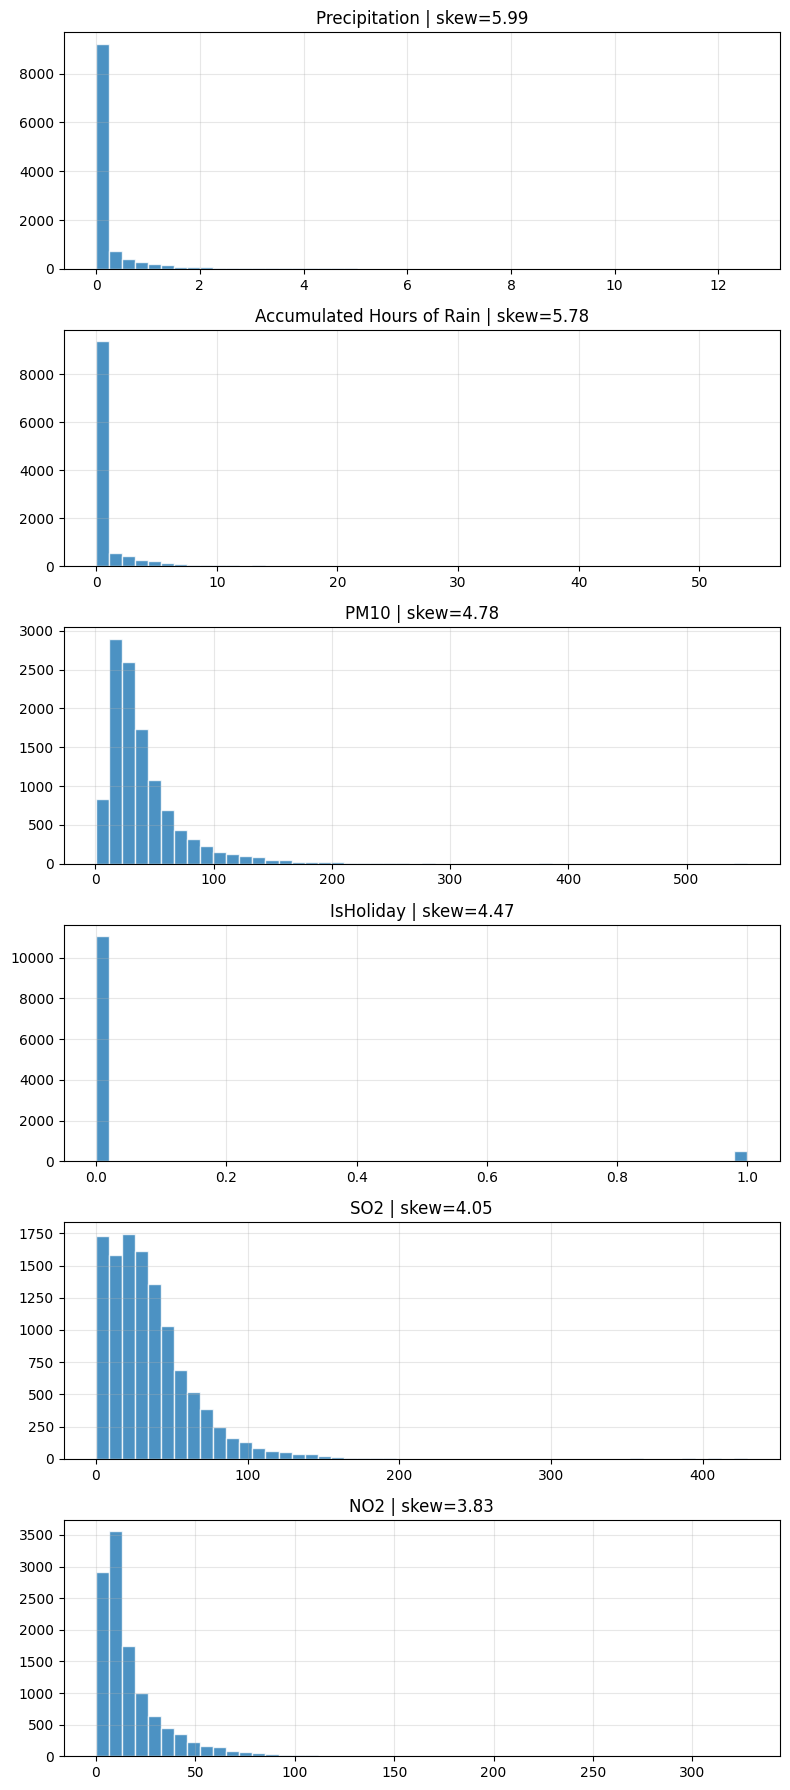

In [6]:
cols_to_plot = strong_skew.index.tolist()[:6]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(8, 3*len(cols_to_plot)))
if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df[col].dropna(), bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(f"{col} | skew={df[col].skew():.2f}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Phân chia tập dữ liệu

In [7]:
# đảm bảo index là datetime
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# ===== Split theo tỷ lệ 70/15/15, giữ nguyên thứ tự thời gian =====
n_total = len(df)
train_size = int(n_total * 0.70)
val_size = int(n_total * 0.15)
test_size = n_total - train_size - val_size

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

train_end = train_df.index.max()
val_start = val_df.index.min()
val_end = val_df.index.max()
test_start = test_df.index.min()

print("Kích thước train/val/test:", train_df.shape, val_df.shape, test_df.shape)
print("Moc thoi gian:")
print("train:", train_df.index.min(), "->", train_end)
print("val  :", val_start, "->", val_end)
print("test :", test_start, "->", test_df.index.max())

Kích thước train/val/test: (8092, 21) (1734, 21) (1735, 21)
Moc thoi gian:
train: 2022-01-16 06:00:00 -> 2024-10-23 15:00:00
val  : 2024-10-23 18:00:00 -> 2025-05-28 18:00:00
test : 2025-05-28 21:00:00 -> 2025-12-31 21:00:00


## 5. Biến đổi biến mục tiêu

Do phân phối của PM2.5 thường lệch phải và chứa các giá trị đỉnh, phép biến đổi `log1p` được áp dụng nhằm giảm ảnh hưởng của ngoại lệ và cải thiện độ ổn định khi huấn luyện. Sau dự báo, các giá trị được biến đổi ngược về thang đo ban đầu để đánh giá.

In [8]:
y_train_raw = train_df["PM25"].to_numpy()
y_val_raw = val_df["PM25"].to_numpy()
y_test_raw = test_df["PM25"].to_numpy()

train_log = np.log1p(train_df["PM25"])
val_log = np.log1p(val_df["PM25"])
test_log = np.log1p(test_df["PM25"])

y_train_t = train_log.to_numpy()
y_val_t = val_log.to_numpy()
y_test_t = test_log.to_numpy()

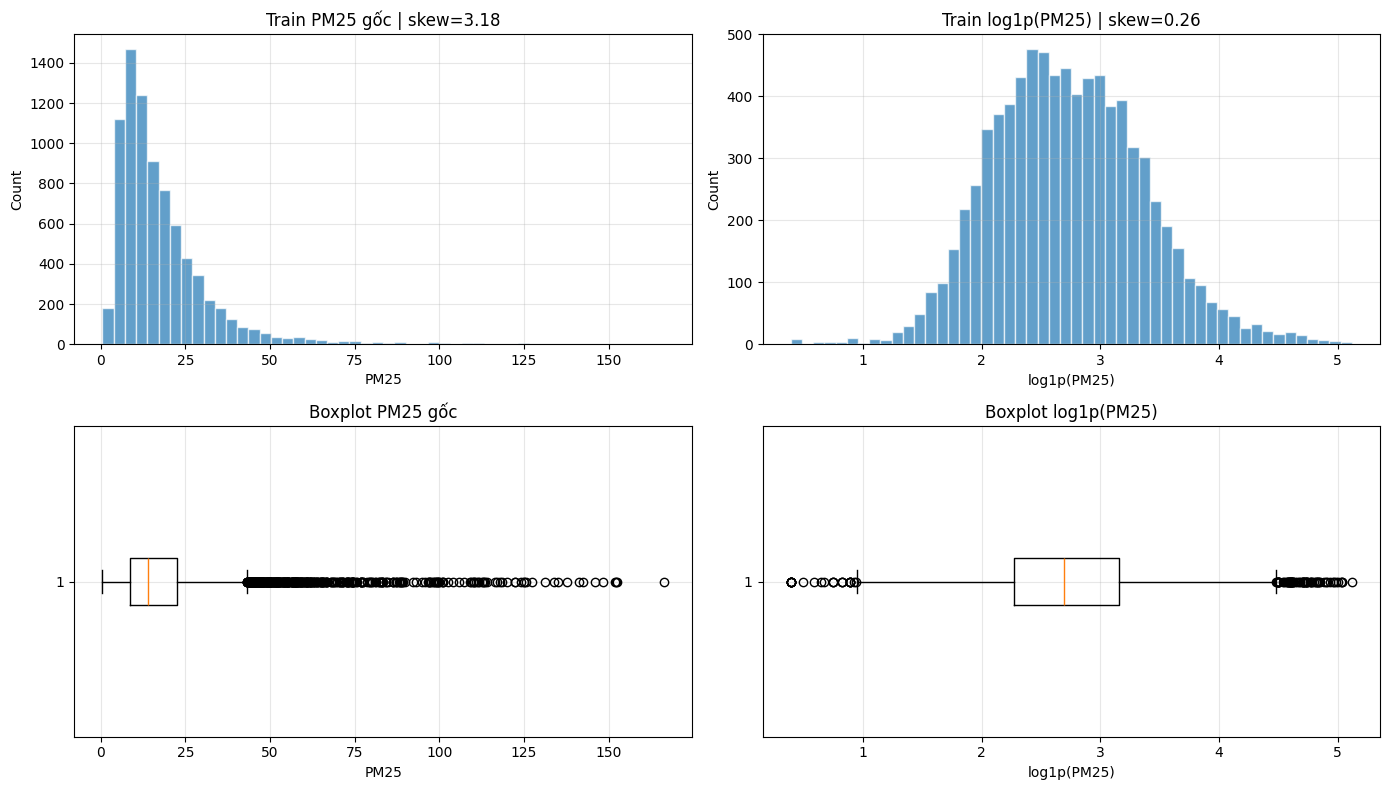

Độ lệch (skew) của dữ liệu gốc: 3.1833155215045283
Độ lệch (skew) sau log: 0.2648290972292766


In [9]:

y_train_raw_1d = y_train_raw.ravel()
y_val_raw_1d   = y_val_raw.ravel()
y_test_raw_1d  = y_test_raw.ravel()

y_train_t_1d = y_train_t.ravel()
y_val_t_1d   = y_val_t.ravel()
y_test_t_1d  = y_test_t.ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Histogram trước log
axes[0, 0].hist(y_train_raw_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 0].set_title(f"Train PM25 gốc | skew={pd.Series(y_train_raw_1d).skew():.2f}")
axes[0, 0].set_xlabel("PM25")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha=0.3)

# 2) Histogram sau log1p
axes[0, 1].hist(y_train_t_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 1].set_title(f"Train log1p(PM25) | skew={pd.Series(y_train_t_1d).skew():.2f}")
axes[0, 1].set_xlabel("log1p(PM25)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3)

# 3) Boxplot trước log
axes[1, 0].boxplot(y_train_raw_1d, vert=False)
axes[1, 0].set_title("Boxplot PM25 gốc")
axes[1, 0].set_xlabel("PM25")
axes[1, 0].grid(alpha=0.3)

# 4) Boxplot sau log1p
axes[1, 1].boxplot(y_train_t_1d, vert=False)
axes[1, 1].set_title("Boxplot log1p(PM25)")
axes[1, 1].set_xlabel("log1p(PM25)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Độ lệch (skew) của dữ liệu gốc:", pd.Series(y_train_raw_1d).skew())
print("Độ lệch (skew) sau log:", pd.Series(y_train_t_1d).skew())

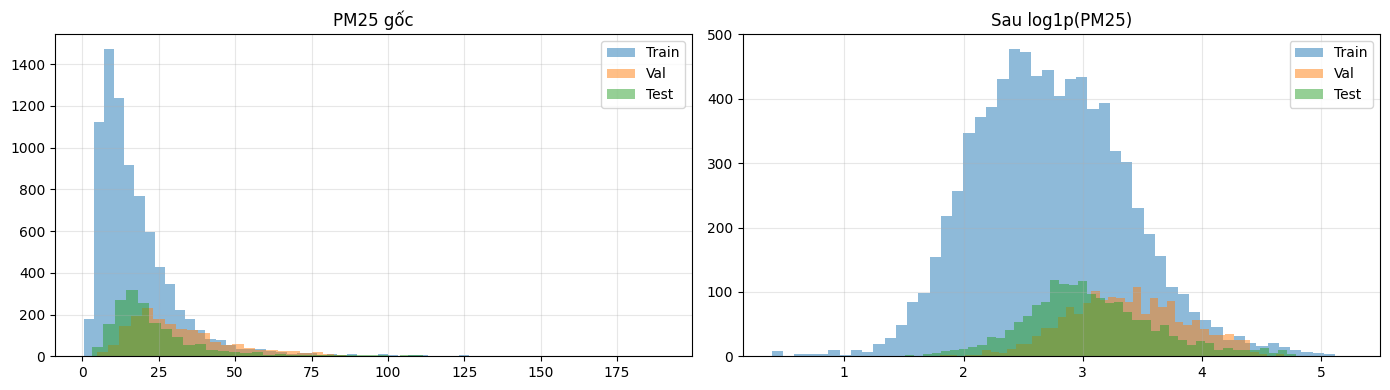

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train_raw.ravel(), bins=50, alpha=0.5, label="Train")
axes[0].hist(y_val_raw.ravel(), bins=50, alpha=0.5, label="Val")
axes[0].hist(y_test_raw.ravel(), bins=50, alpha=0.5, label="Test")
axes[0].set_title("PM25 gốc")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(y_train_t.ravel(), bins=50, alpha=0.5, label="Train")
axes[1].hist(y_val_t.ravel(), bins=50, alpha=0.5, label="Val")
axes[1].hist(y_test_t.ravel(), bins=50, alpha=0.5, label="Test")
axes[1].set_title("Sau log1p(PM25)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

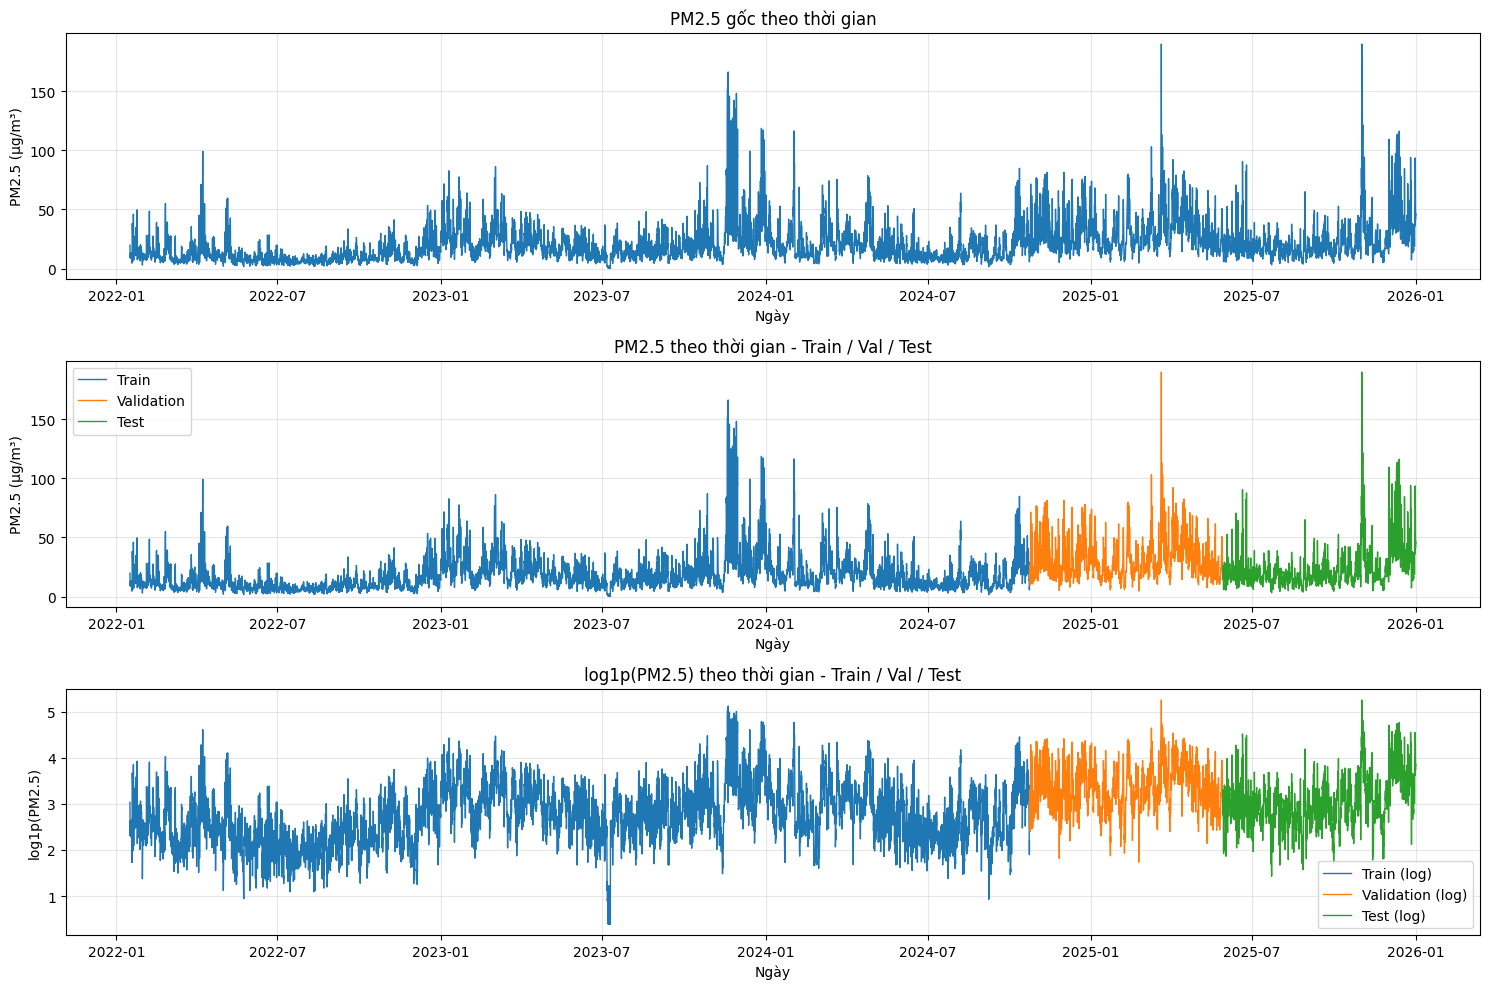

In [11]:


# ===== Tạo log PM25 =====
train_log = np.log1p(train_df["PM25"])
val_log   = np.log1p(val_df["PM25"])
test_log  = np.log1p(test_df["PM25"])

# ===== Vẽ =====
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# 1) PM2.5 gốc toàn bộ theo thời gian
axes[0].plot(df.index, df["PM25"], linewidth=1)
axes[0].set_title("PM2.5 gốc theo thời gian")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_xlabel("Ngày")
axes[0].grid(True, alpha=0.3)

# 2) PM2.5 gốc theo split Train / Val / Test
axes[1].plot(train_df.index, train_df["PM25"], label="Train", linewidth=1)
axes[1].plot(val_df.index, val_df["PM25"], label="Validation", linewidth=1)
axes[1].plot(test_df.index, test_df["PM25"], label="Test", linewidth=1)
axes[1].set_title("PM2.5 theo thời gian - Train / Val / Test")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xlabel("Ngày")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3) log1p(PM2.5) theo split Train / Val / Test
axes[2].plot(train_df.index, train_log, label="Train (log)", linewidth=1)
axes[2].plot(val_df.index, val_log, label="Validation (log)", linewidth=1)
axes[2].plot(test_df.index, test_log, label="Test (log)", linewidth=1)
axes[2].set_title("log1p(PM2.5) theo thời gian - Train / Val / Test")
axes[2].set_ylabel("log1p(PM2.5)")
axes[2].set_xlabel("Ngày")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Tạo đặc trưng đầu vào

Các đặc trưng đầu vào được xây dựng từ thông tin lịch, các biến trễ của PM2.5 và các thống kê theo cùng khung giờ ở những ngày trước đó. Cách thiết kế này giúp mô hình khai thác đồng thời tính chu kỳ và động học ngắn hạn của chuỗi.

In [12]:


df = df.copy()

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

for lag in [1, 8, 16, 24, 32, 40, 48, 56]:
    df[f"PM25_lag_{lag}"] = df["PM25"].shift(lag)

shifted = df["PM25"].shift(1)


df["PM25_diff_1"] = shifted.diff(1)
df["PM25_diff_8"] = shifted.diff(8)
same_hour_lags_3d = ["PM25_lag_8", "PM25_lag_16", "PM25_lag_24"]
same_hour_lags_7d = [
    "PM25_lag_8", "PM25_lag_16", "PM25_lag_24", "PM25_lag_32",
    "PM25_lag_40", "PM25_lag_48", "PM25_lag_56",
]
df["PM25_same_hour_mean_3d"] = df[same_hour_lags_3d].mean(axis=1)
df["PM25_same_hour_mean_7d"] = df[same_hour_lags_7d].mean(axis=1)
df["PM25_same_hour_std_7d"] = df[same_hour_lags_7d].std(axis=1)

df = df.dropna().copy()

base_features = [
    "PM25_lag_1", "PM25_lag_8", "PM25_lag_24", "PM25_lag_56",
    "PM25_diff_1", "PM25_diff_8",
    "PM25_same_hour_mean_3d", "PM25_same_hour_mean_7d", "PM25_same_hour_std_7d",
]

weather_features = [
    "Temperature", "Pressure", "Wind Speed",
    "Clouds", "Precipitation", "Relative Humidity",
    "Accumulated Hours of Rain",
]

pollution_features = ["PM10", "CO", "NO2", "O3", "SO2"]

calendar_features = [
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "IsHoliday",
]

manual_v1_features = (
    base_features
    + ["PM10", "CO", "NO2"]
    + ["Temperature", "Pressure", "Wind Speed", "Relative Humidity", "Precipitation", "Clouds"]
    + calendar_features
)

production_v1_features = base_features + calendar_features

feature_groups = {
    "base": base_features,
    "weather": weather_features,
    "pollution": pollution_features,
    "calendar": calendar_features,
}

candidate_feature_sets = {
    "base": base_features,
    "base_weather": base_features + weather_features,
    "base_weather_pollution": base_features + weather_features + pollution_features,
    "manual_v1": manual_v1_features,
    "production_v1": production_v1_features,
    "optimistic_v1": manual_v1_features,
    "all": base_features + weather_features + pollution_features + calendar_features,
}

GRA_POOL_NAME = "all"
GRA_TOP_K = 15
GRA_RHO = 0.5


def _minmax_01(values):
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmax, vmin):
        return np.zeros_like(values, dtype=np.float64)
    return (values - vmin) / (vmax - vmin)


def compute_gra_scores(X_df, y_series, rho=0.5):
    ref = _minmax_01(np.asarray(y_series, dtype=np.float64).reshape(-1))
    diffs = []
    normalized = {}

    for col in X_df.columns:
        seq = _minmax_01(X_df[col].to_numpy(dtype=np.float64))
        normalized[col] = seq
        diffs.append(np.abs(ref - seq))

    diff_matrix = np.vstack(diffs)
    delta_min = float(np.min(diff_matrix))
    delta_max = float(np.max(diff_matrix))
    if np.isclose(delta_max, 0.0):
        delta_max = 1.0

    rows = []
    for col in X_df.columns:
        diff = np.abs(ref - normalized[col])
        coeff = (delta_min + rho * delta_max) / (diff + rho * delta_max)
        rows.append({
            "feature": col,
            "gra_score": float(np.mean(coeff)),
        })

    return pd.DataFrame(rows).sort_values(["gra_score", "feature"], ascending=[False, True]).reset_index(drop=True)


for name, cols in candidate_feature_sets.items():
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        print(f"{name}: thiếu cột -> {missing_cols}")
    else:
        print(f"{name}: {len(cols)} đặc trưng")

feature_cols = candidate_feature_sets["manual_v1"]
print('Bộ đặc trưng đang dùng:', feature_cols)


base: 9 đặc trưng
base_weather: 16 đặc trưng
base_weather_pollution: 21 đặc trưng
manual_v1: 25 đặc trưng
production_v1: 16 đặc trưng
optimistic_v1: 25 đặc trưng
all: 28 đặc trưng
Bộ đặc trưng đang dùng: ['PM25_lag_1', 'PM25_lag_8', 'PM25_lag_24', 'PM25_lag_56', 'PM25_diff_1', 'PM25_diff_8', 'PM25_same_hour_mean_3d', 'PM25_same_hour_mean_7d', 'PM25_same_hour_std_7d', 'PM10', 'CO', 'NO2', 'Temperature', 'Pressure', 'Wind Speed', 'Relative Humidity', 'Precipitation', 'Clouds', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'IsHoliday']


## 7. Cấu hình

In [ ]:

# CẤU HÌNH CHUNG CHO MÔ HÌNH

LOOKBACK = 112 # 112x3 = 336h = 14 ngày 
CHUNK_HORIZON = 1 # dự báo 3 giờ tiếp theo
ROLLOUT_HORIZON = 24 # 24x3=72h, rollout ra tương lai 24step
N_CHUNKS = ROLLOUT_HORIZON // CHUNK_HORIZON 
HORIZON = CHUNK_HORIZON
EVAL_SIZE = ROLLOUT_HORIZON
STEP_SIZE = ROLLOUT_HORIZON
STEP_HOURS = 3
MAX_FOLDS = 4
EPOCHS = 70
BATCH_SIZE = 64
SEED = 62
TARGET_TRANSFORM_MODE = "log1p"
SELECTED_FEATURE_SET = "all"
OPTIMISTIC_FEATURE_SET = "optimistic_v1"
INNER_VAL_SIZE = 56
PEAK_QUANTILE = 0.90
PEAK_WEIGHT = 1.5
HUBER_DELTA = 1.0
ROLLING_POLICY = "assimilated" 
FEATURE_SET_COMPARE = [SELECTED_FEATURE_SET, OPTIMISTIC_FEATURE_SET]

np.random.seed(SEED)
tf.random.set_seed(SEED)

production_feature_cols = candidate_feature_sets[SELECTED_FEATURE_SET]
optimistic_feature_cols = candidate_feature_sets[OPTIMISTIC_FEATURE_SET]
feature_cols = production_feature_cols

print("Bộ đặc trưng production đang dùng:", SELECTED_FEATURE_SET)
print("Số lượng đặc trưng production:", len(production_feature_cols))
print("LOOKBACK / CHUNK_HORIZON / ROLLOUT_HORIZON:", LOOKBACK, CHUNK_HORIZON, ROLLOUT_HORIZON)
print("MAX_FOLDS, EPOCHS:", MAX_FOLDS, EPOCHS)
print("INNER_VAL_SIZE:", INNER_VAL_SIZE)
print("TARGET_TRANSFORM_MODE:", TARGET_TRANSFORM_MODE)


Bộ đặc trưng production đang dùng: all
Số lượng đặc trưng production: 28
LOOKBACK / CHUNK_HORIZON / ROLLOUT_HORIZON: 84 1 24
MAX_FOLDS, EPOCHS: 4 70
INNER_VAL_SIZE: 56
TARGET_TRANSFORM_MODE: log1p



## 8. Xây dựng mô hình Seq2Seq GRU

Mô hình được thiết kế theo kiến trúc **encoder-decoder** sử dụng **GRU (Gated Recurrent Unit)**, cho phép học các quan hệ phụ thuộc theo thời gian trong chuỗi quan sát và sinh ra nhiều bước dự báo liên tiếp. Kiến trúc này đặc biệt phù hợp với các bài toán dự báo chuỗi thời gian nhiều bước, khi mô hình cần tận dụng thông tin từ quá khứ để dự đoán toàn bộ một đoạn tương lai.

Bên cạnh đó, cơ chế **attention** được tích hợp như một tùy chọn mở rộng nhằm giúp mô hình tập trung tốt hơn vào những mốc thông tin quan trọng trong chuỗi lịch sử, thay vì chỉ phụ thuộc vào trạng thái ẩn cuối cùng của encoder. Nhờ đó, khả năng biểu diễn ngữ cảnh và chất lượng dự báo của mô hình có thể được cải thiện, đặc biệt trong các trường hợp chuỗi dữ liệu có tính biến động phức tạp.

In [ ]:
# ===== Xây dựng mô hình Seq2Seq GRU + Attention =====
def make_sequences(X, y, lookback, horizon):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    X_seq, decoder_seq, y_seq = [], [], []
    max_start = len(X) - lookback - horizon + 1
    if max_start <= 0:
        return (
            np.empty((0, lookback, X.shape[1]), dtype=np.float32),
            np.empty((0, horizon, 1), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
        )

    for i in range(max_start):
        X_seq.append(X[i:i + lookback])
        y_future = y[i + lookback:i + lookback + horizon]
        decoder_seed = np.concatenate([[y[i + lookback - 1]], y_future[:-1]]).astype(np.float32)
        decoder_seq.append(decoder_seed.reshape(-1, 1))
        y_seq.append(y_future)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(decoder_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
    )


def build_gru_model(
    lookback,
    n_features,
    horizon,
    gru_units=(128, 64),
    dense_units=128,
    dropout=0.2,
    recurrent_dropout=0.0,
    learning_rate=2e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
    use_attention=False,
):
    if isinstance(gru_units, int):
        gru_units = (gru_units, max(gru_units // 2, 32))
    elif len(gru_units) == 1:
        gru_units = (gru_units[0], max(gru_units[0] // 2, 32))

    encoder_units = gru_units[0]
    decoder_units = tuple(gru_units[1:]) if len(gru_units) > 1 else (max(encoder_units // 2, 32),)
    decoder_last_units = decoder_units[-1]
    decoder_first_units = decoder_units[0]
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, 1), name="decoder_inputs")

    encoder_outputs, encoder_state = tf.keras.layers.GRU(
        encoder_units,
        return_sequences=True,
        return_state=True,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=regularizer,
        name="encoder_gru",
    )(encoder_inputs)

    if encoder_units != decoder_first_units:
        decoder_initial_state = tf.keras.layers.Dense(
            decoder_first_units,
            activation="tanh",
            kernel_regularizer=regularizer,
            name="decoder_init_projection",
        )(encoder_state)
    else:
        decoder_initial_state = encoder_state

    x = decoder_inputs

    for i, units in enumerate(decoder_units, start=1):
        x = tf.keras.layers.GRU(
            units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=regularizer,
            name=f"decoder_gru_{i}",
        )(
            x,
            initial_state=[decoder_initial_state] if i == 1 else None,
        )

    decoder_outputs = x

    if use_attention:
        attention_values = encoder_outputs
        if encoder_units != decoder_last_units:
            attention_values = tf.keras.layers.Dense(
                decoder_last_units,
                kernel_regularizer=regularizer,
                name="encoder_attention_projection",
            )(attention_values)

        attention_context = tf.keras.layers.AdditiveAttention(name="temporal_attention")(
            [decoder_outputs, attention_values]
        )
        x = tf.keras.layers.Concatenate(name="decoder_attention_concat")(
            [decoder_outputs, attention_context]
        )
    else:
        x = decoder_outputs

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(
                dense_units,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=regularizer,
            ),
            name="time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="decoder_dropout")(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1),
        name="time_distributed_output",
    )(x)

    outputs = tf.keras.layers.Reshape((horizon,), name="forecast_output")(x)

    model_name = "seq2seq_gru_attention" if use_attention else "seq2seq_gru"
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def build_lstm_model(
    lookback,
    n_features,
    horizon,
    lstm_units=(128, 64),
    dense_units=128,
    dropout=0.2,
    recurrent_dropout=0.0,
    learning_rate=2e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
    use_attention=False,
):
    if isinstance(lstm_units, int):
        lstm_units = (lstm_units, max(lstm_units // 2, 32))
    elif len(lstm_units) == 1:
        lstm_units = (lstm_units[0], max(lstm_units[0] // 2, 32))

    encoder_units = lstm_units[0]
    decoder_units = tuple(lstm_units[1:]) if len(lstm_units) > 1 else (max(encoder_units // 2, 32),)
    decoder_first_units = decoder_units[0]
    decoder_last_units = decoder_units[-1]
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="lstm_encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, 1), name="lstm_decoder_inputs")

    encoder_outputs, encoder_state_h, encoder_state_c = tf.keras.layers.LSTM(
        encoder_units,
        return_sequences=True,
        return_state=True,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=regularizer,
        name="encoder_lstm",
    )(encoder_inputs)

    if encoder_units != decoder_first_units:
        decoder_init_h = tf.keras.layers.Dense(decoder_first_units, activation="tanh", kernel_regularizer=regularizer, name="lstm_decoder_init_h")(encoder_state_h)
        decoder_init_c = tf.keras.layers.Dense(decoder_first_units, activation="tanh", kernel_regularizer=regularizer, name="lstm_decoder_init_c")(encoder_state_c)
    else:
        decoder_init_h = encoder_state_h
        decoder_init_c = encoder_state_c

    x = decoder_inputs
    for i, units in enumerate(decoder_units, start=1):
        x = tf.keras.layers.LSTM(
            units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=regularizer,
            name=f"decoder_lstm_{i}",
        )(x, initial_state=[decoder_init_h, decoder_init_c] if i == 1 else None)

    decoder_outputs = x

    if use_attention:
        attention_values = encoder_outputs
        if encoder_units != decoder_last_units:
            attention_values = tf.keras.layers.Dense(decoder_last_units, kernel_regularizer=regularizer, name="lstm_encoder_attention_projection")(attention_values)

        attention_context = tf.keras.layers.AdditiveAttention(name="lstm_temporal_attention")([decoder_outputs, attention_values])
        x = tf.keras.layers.Concatenate(name="lstm_decoder_attention_concat")([decoder_outputs, attention_context])
    else:
        x = decoder_outputs

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(dense_units, activation="relu", kernel_initializer="he_normal", kernel_regularizer=regularizer),
            name="lstm_time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="lstm_decoder_dropout")(x)

    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1), name="lstm_time_distributed_output")(x)
    outputs = tf.keras.layers.Reshape((horizon,), name="lstm_forecast_output")(x)

    model_name = "seq2seq_lstm_attention" if use_attention else "seq2seq_lstm"
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs, name=model_name)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm), loss=loss_fn, metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")])
    return model


def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout, l2_reg=0.0, name="tcn_block"):
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    shortcut = x

    y = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
        activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizer,
        name=f"{name}_conv1",
    )(x)
    y = tf.keras.layers.Dropout(dropout, name=f"{name}_drop1")(y)
    y = tf.keras.layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
        activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizer,
        name=f"{name}_conv2",
    )(y)
    y = tf.keras.layers.Dropout(dropout, name=f"{name}_drop2")(y)

    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same",
            kernel_regularizer=regularizer,
            name=f"{name}_proj",
        )(shortcut)

    added = tf.keras.layers.Add(name=f"{name}_add")([shortcut, y])
    return tf.keras.layers.Activation("relu", name=f"{name}_relu")(added)


def build_tcn_seq2seq_model(
    lookback,
    n_features,
    horizon,
    encoder_filters=(64, 64, 128),
    decoder_filters=(64, 64),
    kernel_size=3,
    dilations=(1, 2, 4, 8),
    dense_units=128,
    dropout=0.15,
    learning_rate=7e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
):
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="tcn_encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, 1), name="tcn_decoder_inputs")

    x_enc = encoder_inputs
    for block_idx, filters in enumerate(encoder_filters, start=1):
        for dilation in dilations:
            x_enc = tcn_residual_block(
                x_enc,
                filters=filters,
                kernel_size=kernel_size,
                dilation_rate=dilation,
                dropout=dropout,
                l2_reg=l2_reg,
                name=f"tcn_encoder_b{block_idx}_d{dilation}",
            )

    context = tf.keras.layers.GlobalAveragePooling1D(name="tcn_context_pool")(x_enc)
    context = tf.keras.layers.Dense(
        decoder_filters[-1],
        activation="relu",
        kernel_regularizer=regularizer,
        name="tcn_context_dense",
    )(context)
    context = tf.keras.layers.RepeatVector(horizon, name="tcn_repeat_context")(context)

    x_dec = decoder_inputs
    for block_idx, filters in enumerate(decoder_filters, start=1):
        for dilation in dilations:
            x_dec = tcn_residual_block(
                x_dec,
                filters=filters,
                kernel_size=kernel_size,
                dilation_rate=dilation,
                dropout=dropout,
                l2_reg=l2_reg,
                name=f"tcn_decoder_b{block_idx}_d{dilation}",
            )

    x = tf.keras.layers.Concatenate(name="tcn_decoder_concat")([x_dec, context])

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(
                dense_units,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=regularizer,
            ),
            name="tcn_time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="tcn_decoder_dropout")(x)

    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1), name="tcn_time_distributed_output")(x)
    outputs = tf.keras.layers.Reshape((horizon,), name="tcn_forecast_output")(x)

    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs, name="seq2seq_tcn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def make_weighted_huber_loss(peak_threshold, peak_weight=2.0, delta=1.0, horizon=72):
    peak_threshold = tf.constant(float(peak_threshold), dtype=tf.float32)
    peak_weight = tf.constant(float(peak_weight), dtype=tf.float32)
    delta = tf.constant(float(delta), dtype=tf.float32)
    raw_step_weights = tf.reshape(tf.linspace(1.0, 1.8, horizon), (1, horizon))
    step_weights = raw_step_weights / tf.reduce_mean(raw_step_weights)

    def loss(y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)
        huber = tf.where(
            abs_error <= delta,
            0.5 * tf.square(error),
            delta * (abs_error - 0.5 * delta),
        )
        peak_mask = tf.cast(y_true >= peak_threshold, tf.float32)
        peak_weights = 1.0 + peak_weight * peak_mask
        weighted = huber * peak_weights * step_weights
        return tf.reduce_mean(weighted)

    return loss


## 9. Mô hình CNN-GRU

In [16]:
# Mô hình CNN-GRU
def build_cnn_gru_model(
    lookback,
    n_features,
    horizon,
    conv_filters=(64, 64),
    kernel_size=5,
    pool_size=2,
    gru_units=(128, 64),
    dense_units=128,
    dropout=0.2,
    recurrent_dropout=0.0,
    learning_rate=5e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
    use_attention=False,
):
    if isinstance(conv_filters, int):
        conv_filters = (conv_filters,)

    if isinstance(gru_units, int):
        gru_units = (gru_units, max(gru_units // 2, 32))
    elif len(gru_units) == 1:
        gru_units = (gru_units[0], max(gru_units[0] // 2, 32))

    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="cnn_encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, 1), name="cnn_decoder_inputs")

    x_enc = encoder_inputs
    for i, filters in enumerate(conv_filters, start=1):
        x_enc = tf.keras.layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name=f"encoder_conv_{i}",
        )(x_enc)
        x_enc = tf.keras.layers.MaxPooling1D(
            pool_size=pool_size,
            padding="same",
            name=f"encoder_pool_{i}",
        )(x_enc)
        x_enc = tf.keras.layers.Dropout(dropout, name=f"encoder_conv_dropout_{i}")(x_enc)

    encoder_units = gru_units[0]
    decoder_units = tuple(gru_units[1:]) if len(gru_units) > 1 else (max(encoder_units // 2, 32),)
    decoder_first_units = decoder_units[0]
    decoder_last_units = decoder_units[-1]

    encoder_outputs, encoder_state = tf.keras.layers.GRU(
        encoder_units,
        return_sequences=True,
        return_state=True,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=regularizer,
        name="cnn_encoder_gru",
    )(x_enc)

    if encoder_units != decoder_first_units:
        decoder_initial_state = tf.keras.layers.Dense(
            decoder_first_units,
            activation="tanh",
            kernel_regularizer=regularizer,
            name="cnn_decoder_init_projection",
        )(encoder_state)
    else:
        decoder_initial_state = encoder_state

    x = decoder_inputs
    for i, units in enumerate(decoder_units, start=1):
        x = tf.keras.layers.GRU(
            units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=regularizer,
            name=f"cnn_decoder_gru_{i}",
        )(
            x,
            initial_state=[decoder_initial_state] if i == 1 else None,
        )

    decoder_outputs = x

    if use_attention:
        attention_values = encoder_outputs
        if encoder_units != decoder_last_units:
            attention_values = tf.keras.layers.Dense(
                decoder_last_units,
                kernel_regularizer=regularizer,
                name="cnn_encoder_attention_projection",
            )(attention_values)

        attention_context = tf.keras.layers.AdditiveAttention(name="cnn_temporal_attention")(
            [decoder_outputs, attention_values]
        )
        x = tf.keras.layers.Concatenate(name="cnn_decoder_attention_concat")(
            [decoder_outputs, attention_context]
        )
    else:
        x = decoder_outputs

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(
                dense_units,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=regularizer,
            ),
            name="cnn_time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="cnn_decoder_dropout")(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1),
        name="cnn_time_distributed_output",
    )(x)

    outputs = tf.keras.layers.Reshape((horizon,), name="cnn_forecast_output")(x)

    model_name = "cnn_gru_attention" if use_attention else "cnn_gru"
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


CNN_GRU_MODEL_KWARGS = {
    "conv_filters": (64, 128),
    "kernel_size": 5,
    "pool_size": 2,
    "gru_units": (128, 64),
    "dense_units": 128,
    "dropout": 0.15,
    "recurrent_dropout": 0.0,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
    "use_attention": True,
}
CNN_GRU_MODEL_LABEL = "CNN-GRU + Attention" if CNN_GRU_MODEL_KWARGS.get("use_attention", False) else "CNN-GRU"
print("CNN_GRU_MODEL_KWARGS sẵn sàng:", CNN_GRU_MODEL_KWARGS)
print("CNN_GRU_MODEL_LABEL:", CNN_GRU_MODEL_LABEL)

CNN_GRU_MODEL_KWARGS sẵn sàng: {'conv_filters': (64, 128), 'kernel_size': 5, 'pool_size': 2, 'gru_units': (128, 64), 'dense_units': 128, 'dropout': 0.15, 'recurrent_dropout': 0.0, 'learning_rate': 0.0007, 'l2_reg': 1e-05, 'clipnorm': 1.0, 'use_attention': True}
CNN_GRU_MODEL_LABEL: CNN-GRU + Attention


## 10. Đánh giá

Hiệu năng mô hình được đánh giá bằng các chỉ số **MAE**, **RMSE** và **MAPE** để phản ánh sai số dự báo trên toàn bộ tập dữ liệu. Ngoài ra, chỉ số **`peak_mae`** được sử dụng để theo dõi sai số tại các điểm đỉnh, qua đó đánh giá khả năng dự báo của mô hình trong những giai đoạn ô nhiễm tăng mạnh.

In [17]:
# ===== Metrics + aggregation =====

# tính toán các metric MAE, RMSE, MAPE tổng thể và riêng cho các điểm đỉnh (peak) dựa trên ngưỡng quantile.
def compute_regression_metrics(y_true_flat, y_pred_flat, peak_quantile=0.90):
    y_true_flat = np.asarray(y_true_flat, dtype=np.float64).reshape(-1)
    y_pred_flat = np.asarray(y_pred_flat, dtype=np.float64).reshape(-1)

    metrics = {
        "mae": mean_absolute_error(y_true_flat, y_pred_flat),
        "rmse": np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)),
        "mape": np.mean(
            np.abs((y_true_flat - y_pred_flat) / np.clip(np.abs(y_true_flat), 1e-6, None))
        ) * 100,
    }

    peak_threshold = float(np.quantile(y_true_flat, peak_quantile))
    peak_mask = y_true_flat >= peak_threshold
    metrics["peak_threshold"] = peak_threshold
    metrics["peak_mae"] = mean_absolute_error(y_true_flat[peak_mask], y_pred_flat[peak_mask]) if np.any(peak_mask) else np.nan
    return metrics


def aggregate_multistep_forecasts(eval_index, y_true_2d, y_pred_2d):
    rows = []
    y_true_2d = np.asarray(y_true_2d, dtype=np.float64)
    y_pred_2d = np.asarray(y_pred_2d, dtype=np.float64)

    for seq_idx in range(y_pred_2d.shape[0]):
        for h in range(y_pred_2d.shape[1]):
            rows.append({
                "timestamp": eval_index[seq_idx + h],
                "horizon_step": h + 1,
                "y_true": y_true_2d[seq_idx, h],
                "y_pred": y_pred_2d[seq_idx, h],
            })

    long_df = pd.DataFrame(rows)
    agg_df = (
        long_df.groupby("timestamp", as_index=False)
        .agg(
            y_true=("y_true", "mean"),
            y_pred=("y_pred", "mean"),
            pred_std=("y_pred", "std"),
            n_votes=("y_pred", "size"),
        )
        .sort_values("timestamp")
    )
    agg_df["pred_std"] = agg_df["pred_std"].fillna(0.0)
    return long_df, agg_df


# Tính metric riêng cho từng horizon step.
def compute_horizon_step_metrics(long_df, peak_quantile=0.90):
    rows = []
    for horizon_step, step_df in long_df.groupby("horizon_step", sort=True):
        metrics = compute_regression_metrics(
            step_df["y_true"].to_numpy(),
            step_df["y_pred"].to_numpy(),
            peak_quantile=peak_quantile,
        )
        rows.append({
            "horizon_step": int(horizon_step),
            "n_points": int(len(step_df)),
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
            "peak_mae": metrics["peak_mae"],
            "peak_threshold": metrics["peak_threshold"],
        })
    return pd.DataFrame(rows)


# Gom toàn bộ quy trình đánh giá multi-step forecasting: từ long format, aggregate theo timestamp, tính metric theo horizon step, và metric tổng thể.
def summarize_multistep_predictions(eval_index, y_true_2d, y_pred_2d, peak_quantile=0.90):
    long_df, agg_df = aggregate_multistep_forecasts(eval_index, y_true_2d, y_pred_2d)
    horizon_metrics_df = compute_horizon_step_metrics(long_df, peak_quantile=peak_quantile)
    step1_df = long_df[long_df["horizon_step"] == 1].sort_values("timestamp").reset_index(drop=True)

    raw_metrics = compute_regression_metrics(
        np.asarray(y_true_2d, dtype=np.float64).reshape(-1),
        np.asarray(y_pred_2d, dtype=np.float64).reshape(-1),
        peak_quantile=peak_quantile,
    )
    step1_metrics = compute_regression_metrics(
        step1_df["y_true"].to_numpy(),
        step1_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )
    agg_metrics = compute_regression_metrics(
        agg_df["y_true"].to_numpy(),
        agg_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )

    return {
        "long_df": long_df,
        "agg_df": agg_df,
        "step1_df": step1_df,
        "horizon_metrics_df": horizon_metrics_df,
        "raw_metrics": raw_metrics,
        "step1_metrics": step1_metrics,
        "agg_metrics": agg_metrics,
    }


In [20]:
def transform_target(y_raw, scaler=None, fit=False, mode="log1p"):
    y_raw = np.asarray(y_raw, dtype=np.float64).reshape(-1)

    y_clip = np.clip(y_raw, 0.0, None)

    if mode == "log1p":
        y_t = np.log1p(y_clip).reshape(-1, 1)
    elif mode == "sqrt":
        y_t = np.sqrt(y_clip).reshape(-1, 1)
    elif mode == "raw":
        y_t = y_clip.reshape(-1, 1)
    else:
        raise ValueError(f"Chế độ biến đổi không hợp lệ: {mode}")

    if fit:
        scaler = StandardScaler()
        scaler.fit(y_t)
    elif scaler is None:
        raise ValueError("Khi fit=False, scaler không được để trống")

    y_scaled = scaler.transform(y_t).reshape(-1)
    return y_scaled, scaler


def inverse_target(y_scaled, scaler, mode="log1p"):
    y_scaled = np.asarray(y_scaled, dtype=np.float64)
    original_shape = y_scaled.shape
    y_unscaled = scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(-1)

    if mode == "log1p":
        y_raw = np.expm1(y_unscaled)
    elif mode == "sqrt":
        y_raw = np.square(np.clip(y_unscaled, 0.0, None))
    elif mode == "raw":
        y_raw = y_unscaled
    else:
        raise ValueError(f"Chế độ biến đổi không hợp lệ: {mode}")

    y_raw = np.clip(y_raw, 0.0, None)
    return y_raw.reshape(original_shape)

## 11. Chuẩn bị dữ liệu cho huấn luyện và suy luận

Dữ liệu được chuẩn hóa, biến đổi biến mục tiêu và đóng gói thành các chuỗi đầu vào phù hợp với kiến trúc mô hình. Việc duy trì quy trình tiền xử lý nhất quán giữa tập huấn luyện, kiểm định và kiểm tra là cần thiết để bảo đảm tính công bằng và độ tin cậy của quá trình đánh giá.

In [18]:
# ===== Data prep for train/eval =====

PRODUCTION_LAGS = [1, 8, 16, 24, 32, 40, 48, 56]



def build_history_feature_frame(raw_df):
    raw_df = raw_df.copy().sort_index()

    raw_df["hour"] = raw_df.index.hour
    raw_df["dayofweek"] = raw_df.index.dayofweek
    raw_df["month"] = raw_df.index.month
    raw_df["hour_sin"] = np.sin(2 * np.pi * raw_df["hour"] / 24)
    raw_df["hour_cos"] = np.cos(2 * np.pi * raw_df["hour"] / 24)
    raw_df["dow_sin"] = np.sin(2 * np.pi * raw_df["dayofweek"] / 7)
    raw_df["dow_cos"] = np.cos(2 * np.pi * raw_df["dayofweek"] / 7)
    raw_df["month_sin"] = np.sin(2 * np.pi * raw_df["month"] / 12)
    raw_df["month_cos"] = np.cos(2 * np.pi * raw_df["month"] / 12)

    for lag in PRODUCTION_LAGS:
        raw_df[f"PM25_lag_{lag}"] = raw_df["PM25"].shift(lag)

    shifted = raw_df["PM25"].shift(1)

    raw_df["PM25_diff_1"] = shifted.diff(1)
    raw_df["PM25_diff_8"] = shifted.diff(8)
    same_hour_lags_3d = ["PM25_lag_8", "PM25_lag_16", "PM25_lag_24"]
    same_hour_lags_7d = [
        "PM25_lag_8", "PM25_lag_16", "PM25_lag_24", "PM25_lag_32",
        "PM25_lag_40", "PM25_lag_48", "PM25_lag_56",
    ]
    raw_df["PM25_same_hour_mean_3d"] = raw_df[same_hour_lags_3d].mean(axis=1)
    raw_df["PM25_same_hour_mean_7d"] = raw_df[same_hour_lags_7d].mean(axis=1)
    raw_df["PM25_same_hour_std_7d"] = raw_df[same_hour_lags_7d].std(axis=1)
    return raw_df



def prepare_train_eval_sequences(train_X_df, train_y_df, eval_X_df, eval_y_df, lookback=72, horizon=72, target_mode="log1p"):
    if len(train_X_df) <= lookback:
        raise ValueError("train_X_df ph?i có ít nh?t `lookback` hàng")

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(train_X_df.values)
    X_eval_scaled = x_scaler.transform(eval_X_df.values)

    y_train_scaled, y_scaler = transform_target(
        train_y_df.values.reshape(-1), scaler=None, fit=True, mode=target_mode
    )
    y_eval_scaled, _ = transform_target(
        eval_y_df.values.reshape(-1), scaler=y_scaler, fit=False, mode=target_mode
    )

    X_train_seq, decoder_train_seq, y_train_seq = make_sequences(
        X_train_scaled, y_train_scaled, lookback=lookback, horizon=horizon
    )

    X_context = np.vstack([X_train_scaled[-lookback:], X_eval_scaled])
    y_context = np.concatenate([y_train_scaled[-lookback:], y_eval_scaled])
    X_eval_seq, decoder_eval_seq, y_eval_seq = make_sequences(
        X_context, y_context, lookback=lookback, horizon=horizon
    )

    return (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_eval_seq,
        decoder_eval_seq,
        y_eval_seq,
        x_scaler,
        y_scaler,
    )


def build_inference_inputs(history_raw_df, feature_cols, x_scaler, y_scaler, lookback=72, target_mode="log1p"):
    feature_frame = build_history_feature_frame(history_raw_df)
    feature_frame = feature_frame.dropna(subset=feature_cols + ["PM25"]).copy()
    if len(feature_frame) < lookback:
        raise ValueError("Không d? lịch sử sau khi tạo feature d? d?ng input inference.")

    X_window = feature_frame[feature_cols].tail(lookback).to_numpy(dtype=np.float32)
    X_scaled = x_scaler.transform(X_window)
    last_target_scaled, _ = transform_target(
        np.array([feature_frame["PM25"].iloc[-1]], dtype=np.float32),
        scaler=y_scaler,
        fit=False,
        mode=target_mode,
    )
    return X_scaled[np.newaxis, ...], float(last_target_scaled[0])


def summarize_rollout_predictions(rollout_df, peak_quantile=0.90):
    rollout_df = rollout_df.copy().sort_values("timestamp").reset_index(drop=True)
    rollout_df["pred_std"] = 0.0

    chunk_rows = []
    for chunk_id, chunk_df in rollout_df.groupby("chunk_id", sort=True):
        metrics = compute_regression_metrics(
            chunk_df["y_true"].to_numpy(),
            chunk_df["y_pred"].to_numpy(),
            peak_quantile=peak_quantile,
        )
        chunk_rows.append({
            "chunk_id": int(chunk_id),
            "n_points": int(len(chunk_df)),
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
            "peak_mae": metrics["peak_mae"],
            "peak_threshold": metrics["peak_threshold"],
        })

    chunk_metrics_df = pd.DataFrame(chunk_rows)
    rollout_metrics = compute_regression_metrics(
        rollout_df["y_true"].to_numpy(),
        rollout_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )
    return {
        "timeline_df": rollout_df,
        "chunk_metrics_df": chunk_metrics_df,
        "rollout_metrics": rollout_metrics,
    }


def run_assimilated_rollout(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
):
    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index().iloc[:rollout_horizon]
    if len(future_raw_df) < rollout_horizon:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rows = []
    for chunk_start in range(0, rollout_horizon, chunk_horizon):
        chunk_id = chunk_start // chunk_horizon + 1
        chunk_future = future_raw_df.iloc[chunk_start:chunk_start + chunk_horizon].copy()
        effective_chunk_horizon = len(chunk_future)
        if effective_chunk_horizon == 0:
            break

        X_input, last_target_scaled = build_inference_inputs(
            history_raw_df=history_raw_df,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            target_mode=target_mode,
        )
        decoder_input = np.zeros((1, effective_chunk_horizon, 1), dtype=np.float32)
        decoder_input[0, 0, 0] = last_target_scaled
        y_pred_scaled = np.zeros((effective_chunk_horizon,), dtype=np.float32)

        for step_idx in range(effective_chunk_horizon):
            decoder_forecast = model.predict([X_input, decoder_input], verbose=0)[0]
            y_pred_scaled[step_idx] = decoder_forecast[step_idx]
            if step_idx + 1 < effective_chunk_horizon:
                decoder_input[0, step_idx + 1, 0] = y_pred_scaled[step_idx]

        y_pred = inverse_target(y_pred_scaled, y_scaler, mode=target_mode)

        for step_idx, (timestamp, y_true_value, y_pred_value) in enumerate(
            zip(chunk_future.index, chunk_future["PM25"].to_numpy(dtype=np.float64), y_pred),
            start=1,
        ):
            rows.append({
                "chunk_id": chunk_id,
                "chunk_step": step_idx,
                "global_step": chunk_start + step_idx,
                "timestamp": timestamp,
                "y_true": float(y_true_value),
                "y_pred": float(y_pred_value),
            })

        history_raw_df = pd.concat([history_raw_df, chunk_future], axis=0)

    rollout_df = pd.DataFrame(rows)
    if len(rollout_df) != rollout_horizon:
        raise ValueError("Rollout không đúng số bước yêu cầu.")

    return summarize_rollout_predictions(rollout_df, peak_quantile=PEAK_QUANTILE)


def run_backtest_over_full_test(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
):
    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index()
    if len(future_raw_df) < chunk_horizon:
        raise ValueError("Không đủ dữ liệu test để backtest.")

    timeline_frames = []
    chunk_metric_frames = []
    window_rows = []
    global_chunk_id = 0

    for window_id, start in enumerate(range(0, len(future_raw_df), rollout_horizon), start=1):
        window_future = future_raw_df.iloc[start:start + rollout_horizon].copy()
        effective_horizon = len(window_future)
        if effective_horizon == 0:
            break

        window_summary = run_assimilated_rollout(
            model=model,
            history_raw_df=history_raw_df,
            future_raw_df=window_future,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            chunk_horizon=chunk_horizon,
            rollout_horizon=effective_horizon,
            target_mode=target_mode,
        )

        window_timeline_df = window_summary["timeline_df"].copy()
        window_timeline_df["window_id"] = window_id
        window_timeline_df["window_start"] = window_future.index.min()
        window_timeline_df["window_end"] = window_future.index.max()
        window_timeline_df["global_test_step"] = np.arange(start + 1, start + len(window_timeline_df) + 1)
        timeline_frames.append(window_timeline_df)

        window_metrics = window_summary["rollout_metrics"]
        window_rows.append({
            "window_id": window_id,
            "window_start": window_future.index.min(),
            "window_end": window_future.index.max(),
            "n_points": len(window_timeline_df),
            "mae": window_metrics["mae"],
            "rmse": window_metrics["rmse"],
            "mape": window_metrics["mape"],
            "peak_mae": window_metrics["peak_mae"],
            "peak_threshold": window_metrics["peak_threshold"],
        })

        window_chunk_metrics_df = window_summary["chunk_metrics_df"].copy()
        window_chunk_metrics_df = window_chunk_metrics_df.rename(columns={"chunk_id": "chunk_id_within_window"})
        window_chunk_metrics_df["window_id"] = window_id
        window_chunk_metrics_df["window_start"] = window_future.index.min()
        window_chunk_metrics_df["window_end"] = window_future.index.max()
        window_chunk_metrics_df["global_chunk_id"] = np.arange(
            global_chunk_id + 1,
            global_chunk_id + len(window_chunk_metrics_df) + 1,
        )
        global_chunk_id += len(window_chunk_metrics_df)
        chunk_metric_frames.append(window_chunk_metrics_df)

        history_raw_df = pd.concat([history_raw_df, window_future], axis=0)

    timeline_df = pd.concat(timeline_frames, ignore_index=True)
    timeline_df = timeline_df.sort_values("timestamp").reset_index(drop=True)
    chunk_metrics_df = pd.concat(chunk_metric_frames, ignore_index=True)
    window_metrics_df = pd.DataFrame(window_rows)
    overall_metrics = compute_regression_metrics(
        timeline_df["y_true"].to_numpy(),
        timeline_df["y_pred"].to_numpy(),
        peak_quantile=PEAK_QUANTILE,
    )
    return {
        "timeline_df": timeline_df,
        "chunk_metrics_df": chunk_metrics_df,
        "window_metrics_df": window_metrics_df,
        "rollout_metrics": overall_metrics,
    }


## 12. Huấn luyện và đánh giá theo walk-forward

Mô hình được đánh giá trên tập validation theo chiến lược **walk-forward** nhằm mô phỏng bối cảnh dự báo thực tế, trong đó mỗi lần dự báo chỉ sử dụng thông tin từ quá khứ. Sau khi lựa chọn cấu hình phù hợp, mô hình được huấn luyện lại trên tập `train + validation` và đánh giá cuối cùng trên tập test tách biệt.



Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 26: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 24: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 31: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 37: ReduceLROnPlateau reducing learning rate to 4.374999844003469e-05.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 30: ReduceLROnPlateau reducing learning rate to 8.749

,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,9.409884,12.728569,30.463456,26.959084,54.667333,1.269434,...,14.668092,5.378300,15.176896,15.176896,140.094421,15.176896,6.633000,6.633000,62.184374,6.633000
1,2,8004,56,24,4.810252,6.741304,23.987196,11.698207,24.934000,1.267513,...,1.390887,0.234133,1.405151,1.405151,7.953686,1.405151,3.366323,3.366323,19.997960,3.366323
2,3,8028,56,24,14.631410,18.741990,33.096805,30.958650,75.279167,1.267356,...,32.448114,16.898978,11.467282,11.467282,74.916914,11.467282,11.849664,11.849664,87.258204,11.849664
3,4,8052,56,24,7.758814,9.479874,21.837104,18.969397,48.290667,1.268150,...,8.597662,3.430467,6.965494,6.965494,25.001772,6.965494,1.525267,1.525267,6.510813,1.525267



=== Bảng tóm tắt validation ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae
0,9.15259,11.922934,5.081054,9.801511,8.183163



Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 28: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 34: ReduceLROnPlateau reducing learning rate to 4.374999844003469e-05.

=== Chỉ số backtest trên toàn bộ tập test ===


...

,window_id,window_start,window_end,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,2025-05-28 21:00:00,2025-05-31 18:00:00,24,4.056861,5.005266,34.958647,3.860456,24.508667
1,2,2025-05-31 21:00:00,2025-06-03 18:00:00,24,5.999784,9.025406,39.339078,17.443017,25.283333
2,3,2025-06-03 21:00:00,2025-06-06 18:00:00,24,2.759145,4.241190,13.609823,7.554632,26.587333
3,4,2025-06-06 21:00:00,2025-06-09 18:00:00,24,7.516217,12.268102,27.479174,27.438606,29.119333
4,5,2025-06-09 21:00:00,2025-06-12 18:00:00,24,6.335230,13.029172,23.012958,23.340823,26.411333
...,...,...,...,...,...,...,...,...,...
68,69,2025-12-19 03:00:00,2025-12-22 00:00:00,24,4.940706,7.334126,12.075652,14.169923,51.293333
69,70,2025-12-22 03:00:00,2025-12-25 00:00:00,24,6.124691,10.311733,15.578701,23.814602,52.400000
70,71,2025-12-25 03:00:00,2025-12-28 00:00:00,24,13.461924,16.887521,40.641695,25.372636,77.946667
71,72,2025-12-28 03:00:00,2025-12-31 00:00:00,24,4.162781,5.225115,15.891888,5.896009,37.720000



=== Chỉ số theo từng chunk trong backtest ===


,chunk_id_within_window,n_points,mae,rmse,mape,peak_mae,peak_threshold,window_id,window_start,window_end,global_chunk_id
0,1,1,4.112480,4.112480,15.748584,4.112480,26.113333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,1
1,2,1,1.240313,1.240313,4.940174,1.240313,25.106667,1,2025-05-28 21:00:00,2025-05-31 18:00:00,2
2,3,1,7.755917,7.755917,52.475755,7.755917,14.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,3
3,4,1,3.328485,3.328485,16.827528,3.328485,19.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,4
4,5,1,3.469989,3.469989,15.893078,3.469989,21.833333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
1730,3,1,15.081547,15.081547,17.729091,15.081547,85.066667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1731
1731,4,1,14.371160,14.371160,23.872359,14.371160,60.200000,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1732
1732,5,1,0.935131,0.935131,2.090457,0.935131,44.733333,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1733
1733,6,1,1.792263,1.792263,3.824174,1.792263,46.866667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1734



=== Bảng tổng hợp kết quả ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,MAPE,best_epoch
0,Seq2Seq GRU + Attention,1735,73,24,1,6.695783,10.932577,27.317059,16


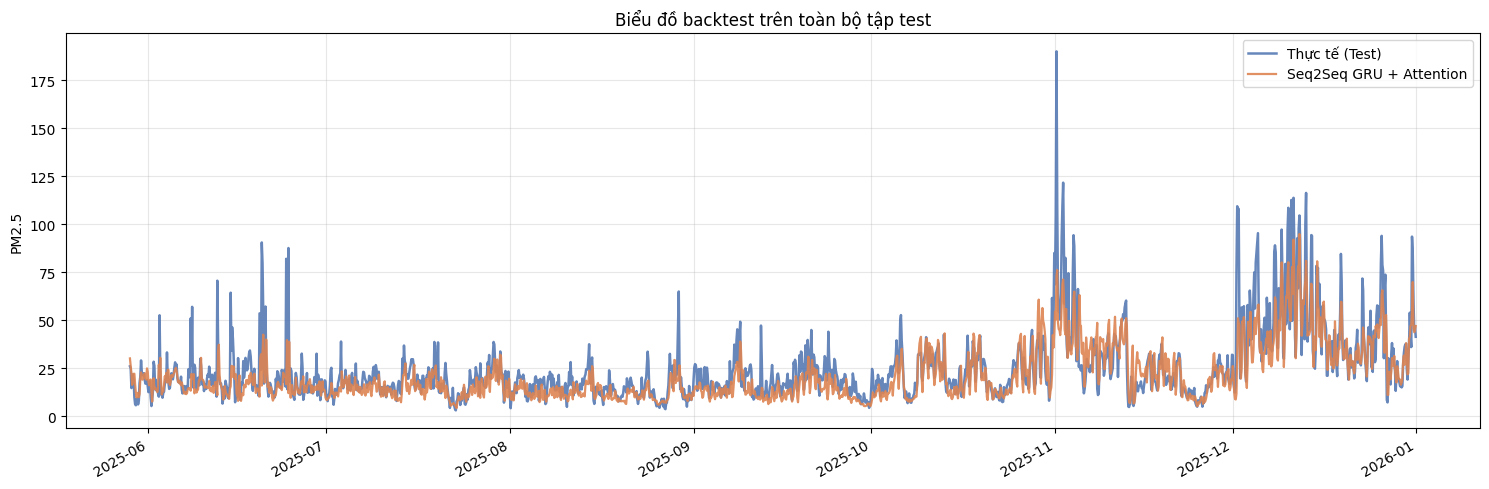

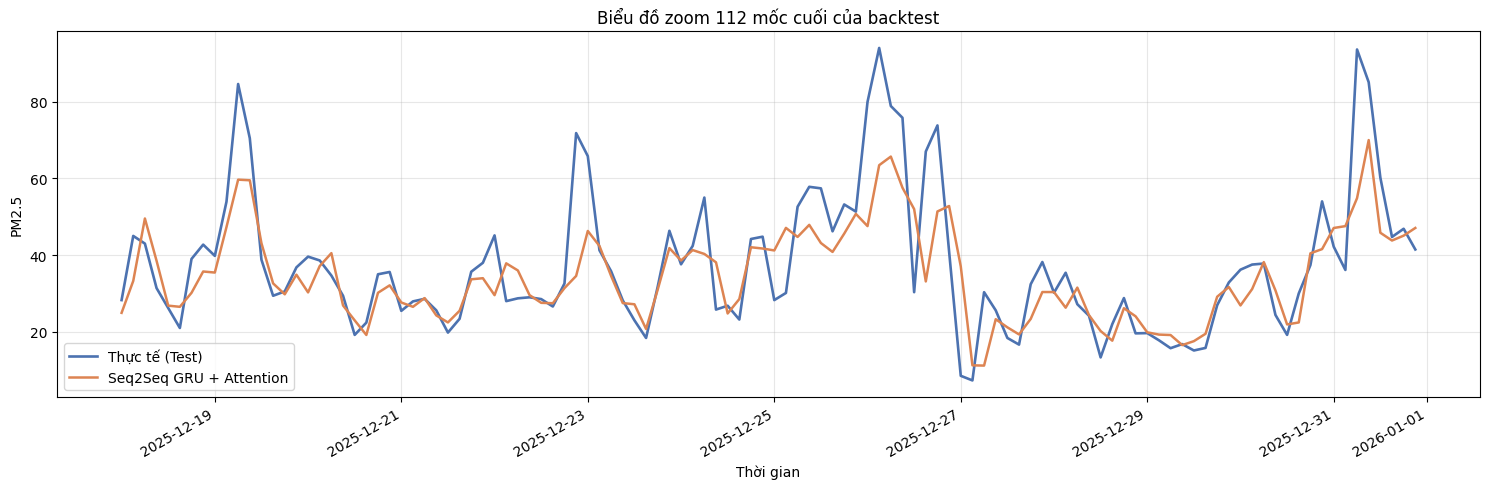

NameError: name 'cnn_gru_plot_df' is not defined

In [ ]:
# ===== Walk-forward validate tren tap val, giu test hold-out =====

df_raw_rollout = df.copy().sort_index()
df_wf = build_history_feature_frame(df_raw_rollout).dropna().copy()

train_wf = df_wf[:train_end].copy()
val_wf = df_wf[val_start:val_end].copy()
test_wf = df_wf[test_start:].copy()

train_raw = df_raw_rollout[:train_end].copy()
val_raw = df_raw_rollout[val_start:val_end].copy()
test_raw = df_raw_rollout[test_start:].copy()

for feature_set_name in [SELECTED_FEATURE_SET, OPTIMISTIC_FEATURE_SET]:
    local_cols = candidate_feature_sets[feature_set_name]
    missing_feature_cols = [c for c in local_cols if c not in df_wf.columns]
    if missing_feature_cols:
        raise ValueError(f"Thiếu các cột feature cho {feature_set_name}: {missing_feature_cols}")

MODEL_KWARGS = {
    "gru_units": (128, 64),
    "dense_units": 128,
    "dropout": 0.15,
    "recurrent_dropout": 0.0,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
    "use_attention": True,
}
MODEL_LABEL = "Seq2Seq GRU + Attention" if MODEL_KWARGS.get("use_attention", False) else "Seq2Seq GRU"

def make_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, min_delta=1e-3),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=1),
    ]


def split_train_inner_val(train_X_df, train_y_df, inner_val_size):
    min_train_rows = LOOKBACK + CHUNK_HORIZON
    if len(train_X_df) <= inner_val_size + min_train_rows:
        raise ValueError(
            f"Không đủ dữ liệu để tách inner val. Cần > {inner_val_size + min_train_rows} rows, nhận {len(train_X_df)}"
        )
    train_core_X = train_X_df.iloc[:-inner_val_size].copy()
    train_core_y = train_y_df.iloc[:-inner_val_size].copy()
    inner_val_X = train_X_df.iloc[-inner_val_size:].copy()
    inner_val_y = train_y_df.iloc[-inner_val_size:].copy()
    return train_core_X, train_core_y, inner_val_X, inner_val_y


def fit_selector_model(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence cho train hoặc inner val. Kiểm tra lại kích thước dữ liệu và lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant(feature_cols_local, history_feature_df, history_raw_df, future_raw_df, model_kwargs, selector_epochs=EPOCHS):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model(
        history_X_df,
        history_y_df,
        best_epoch_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_backtest_over_full_test(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
    }


val_feature_pool = val_wf[feature_cols].copy()
base_train_X = train_wf[feature_cols].copy()
base_train_y = train_wf[["PM25"]].copy()

fold_rows = []
compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model(
        train_core_X, train_core_y, inner_val_X, inner_val_y
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = run_assimilated_rollout(
    model=model,
    history_raw_df=fold_history_raw,
    future_raw_df=fold_eval_raw,
    feature_cols=feature_cols,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    lookback=LOOKBACK,
    chunk_horizon=CHUNK_HORIZON,
    rollout_horizon=ROLLOUT_HORIZON,
    target_mode=TARGET_TRANSFORM_MODE,
)

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        chunk_metrics = chunk_metrics_df.loc[chunk_id]
        fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
        fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
        fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
        fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    fold_rows.append(fold_record)

walkforward_df = pd.DataFrame(fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ===")
display(walkforward_df)

if not walkforward_df.empty:
    val_summary_df = pd.DataFrame([
        {
            "mean_rollout_mae": walkforward_df["rollout_mae"].mean(),
            "mean_rollout_rmse": walkforward_df["rollout_rmse"].mean(),
            "mean_chunk_1_mae": walkforward_df["chunk_1_mae"].mean(),
            "mean_chunk_2_mae": walkforward_df["chunk_2_mae"].mean(),
            "mean_chunk_3_mae": walkforward_df["chunk_3_mae"].mean(),
        }
    ])
    print("\n=== Bảng tóm tắt validation ===")
    display(val_summary_df)


# ===== Train trên train+val và backtest trên toàn bộ test =====
train_val_feature_df = pd.concat([train_wf, val_wf], axis=0)
train_val_raw = pd.concat([train_raw, val_raw], axis=0)
test_backtest_raw = test_raw.copy()
test_rollout_raw = test_backtest_raw.copy()

if len(test_backtest_raw) < CHUNK_HORIZON:
    raise ValueError("Không đủ dữ liệu test để backtest.")

test_variant = fit_test_variant(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

best_epoch_test = test_variant["best_epoch"]
peak_threshold_test_train = test_variant["train_peak_threshold_t"]
peak_threshold_test_full = test_variant["train_full_peak_threshold_t"]
test_eval_summary = test_variant["rollout_summary"]
test_timeline_df = test_eval_summary["timeline_df"].copy()
test_chunk_metrics_df = test_eval_summary["chunk_metrics_df"].copy()
test_window_metrics_df = test_eval_summary["window_metrics_df"].copy()
test_rollout_metrics = test_eval_summary["rollout_metrics"]

test_metrics_df = pd.DataFrame([
    {
        "best_epoch": best_epoch_test,
        "test_rows": len(test_timeline_df),
        "n_backtest_windows": test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": test_rollout_metrics["mae"],
        "test_rmse": test_rollout_metrics["rmse"],
        "test_mape": test_rollout_metrics["mape"],
        "test_peak_mae": test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": peak_threshold_test_train,
        "train_val_peak_threshold_t": peak_threshold_test_full,
    }
])

test_report_df = pd.DataFrame([
    {
        "model": MODEL_LABEL,
        "test_rows": len(test_timeline_df),
        "n_backtest_windows": test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": test_rollout_metrics["mae"],
        "rmse": test_rollout_metrics["rmse"],
        "MAPE": test_rollout_metrics["mape"],
        "best_epoch": best_epoch_test,
    }
])

print("\n=== Chỉ số backtest trên toàn bộ tập test ===")
display(test_metrics_df)

print("\n=== Chỉ số theo từng cửa sổ backtest ===")
display(test_window_metrics_df)

print("\n=== Chỉ số theo từng chunk trong backtest ===")
display(test_chunk_metrics_df)

print("\n=== Bảng tổng hợp kết quả ===")
display(test_report_df)

plot_df = test_timeline_df.copy()

plt.figure(figsize=(15, 5))
plt.plot(plot_df["timestamp"], plot_df["y_true"], label="Thực tế (Test)", linewidth=1.8, color="#4C72B0", alpha=0.85)
plt.plot(plot_df["timestamp"], plot_df["y_pred"], label=MODEL_LABEL, linewidth=1.6, color="#DD8452", alpha=0.9)

plt.title("Biểu đồ backtest trên toàn bộ tập test")
plt.xlabel("")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

zoom_n = min(len(plot_df), int(14 * 24 / STEP_HOURS))
zoom_plot_df = plot_df.tail(zoom_n).copy()

plt.figure(figsize=(15, 5))
plt.plot(zoom_plot_df["timestamp"], zoom_plot_df["y_true"], label="Thực tế (Test)", linewidth=1.9, color="#4C72B0")
plt.plot(zoom_plot_df["timestamp"], zoom_plot_df["y_pred"], label=MODEL_LABEL, linewidth=1.8, color="#DD8452")
plt.title(f"Biểu đồ zoom {zoom_n} mốc cuối của backtest")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

# cnn_gru_zoom_n = min(len(cnn_gru_plot_df), int(14 * 24 / STEP_HOURS))
# cnn_gru_zoom_df = cnn_gru_plot_df.tail(cnn_gru_zoom_n).copy()

# plt.figure(figsize=(15, 5))
# plt.plot(cnn_gru_zoom_df["timestamp"], cnn_gru_zoom_df["y_true"], label="Thực tế (Test)", linewidth=1.9, color="#4C72B0")
# plt.plot(cnn_gru_zoom_df["timestamp"], cnn_gru_zoom_df["y_pred"], label=CNN_GRU_MODEL_LABEL, linewidth=1.8, color="#55A868")
# plt.title(f"Biểu đồ zoom {cnn_gru_zoom_n} mốc cuối của backtest CNN-GRU")
# plt.xlabel("Thời gian")
# plt.ylabel("PM2.5")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.gcf().autofmt_xdate()
# plt.tight_layout()
# plt.show()


## 12. Huấn luyện và đánh giá mô hình CNN-GRU

Sau khi hoàn tất thí nghiệm với mô hình Seq2Seq GRU, notebook tiếp tục huấn luyện biến thể **CNN-GRU** trên cùng pipeline dữ liệu và cùng chiến lược đánh giá. Cách thiết kế này bảo đảm tính nhất quán trong thực nghiệm và tạo cơ sở cho việc so sánh công bằng giữa các mô hình.



Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 36: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 25: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 31: ReduceLROnPlateau reducing learning rate to 4.374999844003469e-05.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 25: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 24: ReduceLROnPlateau reducing learning rate to 8.749

,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,8.565495,11.544885,28.765014,24.004201,54.667333,1.269434,...,4.151004,1.522035,14.856620,14.856620,137.138027,14.856620,6.033609,6.033609,56.565086,6.033609
1,2,8004,56,24,5.010800,6.535393,26.966637,7.536046,24.934000,1.267513,...,13.901947,2.340161,0.566611,0.566611,3.207232,0.566611,4.557980,4.557980,27.077106,4.557980
2,3,8028,56,24,12.184785,15.136239,30.650145,20.585229,75.279167,1.267356,...,0.120218,0.062609,22.250045,22.250045,145.361790,22.250045,9.200468,9.200468,67.750132,9.200468
3,4,8052,56,24,7.144725,8.949768,22.020003,12.001378,48.290667,1.268150,...,14.952555,5.966069,2.371661,2.371661,8.512781,2.371661,3.194577,3.194577,13.636498,3.194577



=== CNN-GRU validation summary ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae
0,8.226451,10.541571,5.340213,12.107385,14.437048



Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 20: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

=== Kết quả backtest CNN-GRU trên toàn bộ tập test ===


...

,chunk_id_within_window,n_points,mae,rmse,mape,peak_mae,peak_threshold,window_id,window_start,window_end,global_chunk_id
0,1,1,0.711299,0.711299,2.723892,0.711299,26.113333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,1
1,2,1,1.262785,1.262785,5.029682,1.262785,25.106667,1,2025-05-28 21:00:00,2025-05-31 18:00:00,2
2,3,1,9.500467,9.500467,64.279207,9.500467,14.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,3
3,4,1,3.501784,3.501784,17.703659,3.501784,19.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,4
4,5,1,4.743293,4.743293,21.725008,4.743293,21.833333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
1730,3,1,33.751354,33.751354,39.676356,33.751354,85.066667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1731
1731,4,1,10.509489,10.509489,17.457623,10.509489,60.200000,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1732
1732,5,1,8.297769,8.297769,18.549408,8.297769,44.733333,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1733
1733,6,1,0.250321,0.250321,0.534113,0.250321,46.866667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1734



=== Bảng tóm tắt kết quả của CNN-GRU ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,MAPE,best_epoch
0,CNN-GRU + Attention,1735,73,24,1,6.382317,11.080042,24.692366,2



=== So sánh hiện có giữa Seq2Seq GRU và CNN-GRU ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,MAPE,best_epoch
0,Seq2Seq GRU + Attention,1735,73,24,1,6.695783,10.932577,27.317059,16
1,CNN-GRU + Attention,1735,73,24,1,6.382317,11.080042,24.692366,2


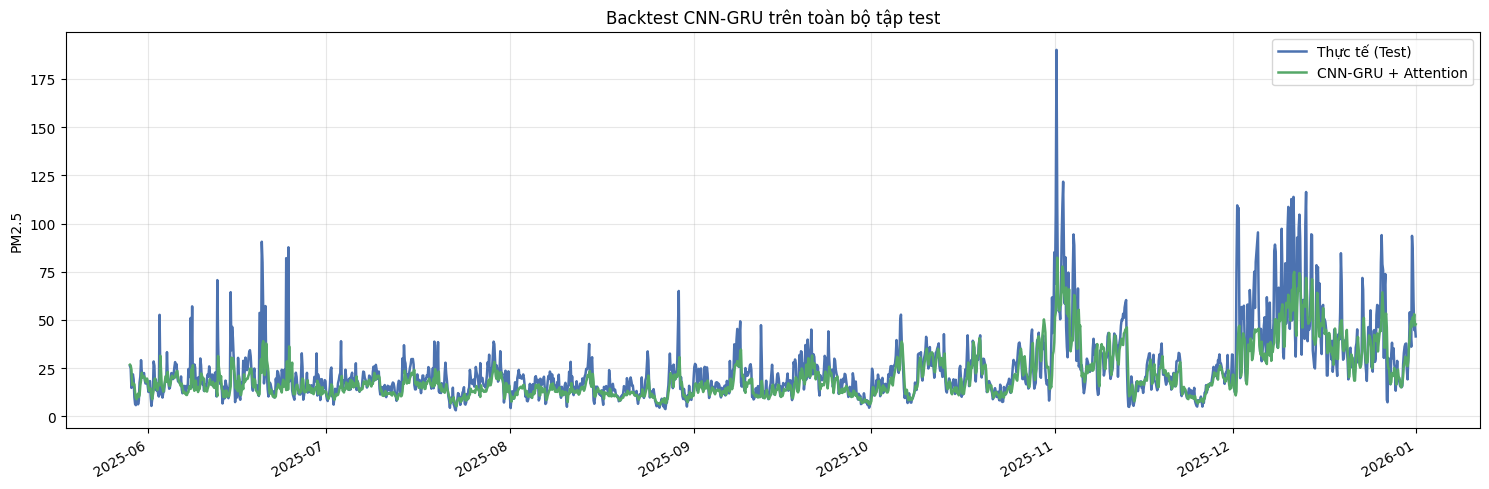

In [ ]:
# ===== CNN-GRU walk-forward validation + hold-out test (separate variables) =====
def fit_selector_model_cnn_gru(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = CNN_GRU_MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence selector cho CNN-GRU. Vui lòng kiểm tra lại kích thước dữ liệu và tham số lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_cnn_gru_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model_cnn_gru(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = CNN_GRU_MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history cho CNN-GRU.")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_cnn_gru_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant_cnn_gru(feature_cols_local, history_feature_df, history_raw_df, future_raw_df, model_kwargs=None, selector_epochs=EPOCHS):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model_cnn_gru(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model_cnn_gru(
        history_X_df,
        history_y_df,
        best_epoch_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_backtest_over_full_test(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
    }


cnn_gru_fold_rows = []
cnn_gru_compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model_cnn_gru(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=CNN_GRU_MODEL_KWARGS,
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = run_assimilated_rollout(
        model=model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )


    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        chunk_metrics = chunk_metrics_df.loc[chunk_id]
        fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
        fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
        fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
        fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    cnn_gru_compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    cnn_gru_fold_rows.append(fold_record)

cnn_gru_walkforward_df = pd.DataFrame(cnn_gru_fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ")

display(cnn_gru_walkforward_df)

if not cnn_gru_walkforward_df.empty:
    cnn_gru_val_summary_df = pd.DataFrame([
        {
            "mean_rollout_mae": cnn_gru_walkforward_df["rollout_mae"].mean(),
            "mean_rollout_rmse": cnn_gru_walkforward_df["rollout_rmse"].mean(),
            "mean_chunk_1_mae": cnn_gru_walkforward_df["chunk_1_mae"].mean(),
            "mean_chunk_2_mae": cnn_gru_walkforward_df["chunk_2_mae"].mean(),
            "mean_chunk_3_mae": cnn_gru_walkforward_df["chunk_3_mae"].mean(),
        }
    ])
    print()
    print("=== CNN-GRU validation summary ===")
    display(cnn_gru_val_summary_df)


cnn_gru_test_variant = fit_test_variant_cnn_gru(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=CNN_GRU_MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

cnn_gru_best_epoch_test = cnn_gru_test_variant["best_epoch"]
cnn_gru_peak_threshold_test_train = cnn_gru_test_variant["train_peak_threshold_t"]
cnn_gru_peak_threshold_test_full = cnn_gru_test_variant["train_full_peak_threshold_t"]
cnn_gru_test_eval_summary = cnn_gru_test_variant["rollout_summary"]
cnn_gru_test_timeline_df = cnn_gru_test_eval_summary["timeline_df"].copy()
cnn_gru_test_chunk_metrics_df = cnn_gru_test_eval_summary["chunk_metrics_df"].copy()
cnn_gru_test_window_metrics_df = cnn_gru_test_eval_summary["window_metrics_df"].copy()
cnn_gru_test_rollout_metrics = cnn_gru_test_eval_summary["rollout_metrics"]

cnn_gru_test_metrics_df = pd.DataFrame([
    {
        "best_epoch": cnn_gru_best_epoch_test,
        "test_rows": len(cnn_gru_test_timeline_df),
        "n_backtest_windows": cnn_gru_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": cnn_gru_test_rollout_metrics["mae"],
        "test_rmse": cnn_gru_test_rollout_metrics["rmse"],
        "test_mape": cnn_gru_test_rollout_metrics["mape"],
        "test_peak_mae": cnn_gru_test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": cnn_gru_peak_threshold_test_train,
        "train_val_peak_threshold_t": cnn_gru_peak_threshold_test_full,
    }
])

cnn_gru_test_report_df = pd.DataFrame([
    {
        "model": CNN_GRU_MODEL_LABEL,
        "test_rows": len(cnn_gru_test_timeline_df),
        "n_backtest_windows": cnn_gru_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": cnn_gru_test_rollout_metrics["mae"],
        "rmse": cnn_gru_test_rollout_metrics["rmse"],
        "MAPE": cnn_gru_test_rollout_metrics["mape"],
        "best_epoch": cnn_gru_best_epoch_test,
    }
])

print()
print("=== Kết quả backtest CNN-GRU trên toàn bộ tập test ===")
display(cnn_gru_test_metrics_df)
print()

print("=== Kết quả CNN-GRU theo từng cửa sổ backtest ===")
display(cnn_gru_test_window_metrics_df)
print()

print("=== Kết quả CNN-GRU theo từng chunk trong backtest ===")
display(cnn_gru_test_chunk_metrics_df)
print()

print("=== Bảng tóm tắt kết quả của CNN-GRU ===")
display(cnn_gru_test_report_df)

if "test_report_df" in globals() and not test_report_df.empty:
    cnn_gru_compare_report_df = pd.concat(
        [test_report_df.copy(), cnn_gru_test_report_df.copy()],
        ignore_index=True,
    )
    print()
    

# cnn_gru_plot_df = cnn_gru_test_timeline_df.copy()
# plt.figure(figsize=(15, 5))
# plt.plot(cnn_gru_plot_df["timestamp"], cnn_gru_plot_df["y_true"], label="Thực tế (Test)", linewidth=1.8, color="#4C72B0")
# plt.plot(cnn_gru_plot_df["timestamp"], cnn_gru_plot_df["y_pred"], label=CNN_GRU_MODEL_LABEL, linewidth=1.8, color="#55A868")

# plt.title("Backtest CNN-GRU trên toàn bộ tập test")
# plt.xlabel("")
# plt.ylabel("PM2.5")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.gcf().autofmt_xdate()
# plt.tight_layout()
# plt.show()


## 13. Huấn luyện và đánh giá mô hình Seq2Seq LSTM




In [ ]:
# ===== Seq2Seq LSTM walk-forward validation + hold-out test =====
LSTM_MODEL_KWARGS = {
    "lstm_units": (128, 64),
    "dense_units": 128,
    "dropout": 0.15,
    "recurrent_dropout": 0.0,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
    "use_attention": True,
}
LSTM_MODEL_LABEL = "Seq2Seq LSTM + Attention" if LSTM_MODEL_KWARGS.get("use_attention", False) else "Seq2Seq LSTM"
print("LSTM_MODEL_KWARGS sẵn sàng:", LSTM_MODEL_KWARGS)
print("LSTM_MODEL_LABEL:", LSTM_MODEL_LABEL)


def fit_selector_model_lstm(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = LSTM_MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence selector cho LSTM. Vui lòng kiểm tra lại kích thước dữ liệu và tham số lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_lstm_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model_lstm(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = LSTM_MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history cho LSTM.")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_lstm_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant_lstm(feature_cols_local, history_feature_df, history_raw_df, future_raw_df, model_kwargs=None, selector_epochs=EPOCHS):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model_lstm(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model_lstm(
        history_X_df,
        history_y_df,
        best_epoch_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_backtest_over_full_test(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
    }


lstm_fold_rows = []
lstm_compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model_lstm(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=LSTM_MODEL_KWARGS,
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = run_assimilated_rollout(
        model=model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        chunk_metrics = chunk_metrics_df.loc[chunk_id]
        fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
        fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
        fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
        fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    lstm_compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    lstm_fold_rows.append(fold_record)

lstm_walkforward_df = pd.DataFrame(lstm_fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ")
display(lstm_walkforward_df)

if not lstm_walkforward_df.empty:
    lstm_val_summary_df = pd.DataFrame([
        {
            "mean_rollout_mae": lstm_walkforward_df["rollout_mae"].mean(),
            "mean_rollout_rmse": lstm_walkforward_df["rollout_rmse"].mean(),
            "mean_chunk_1_mae": lstm_walkforward_df["chunk_1_mae"].mean(),
            "mean_chunk_2_mae": lstm_walkforward_df["chunk_2_mae"].mean() if "chunk_2_mae" in lstm_walkforward_df.columns else np.nan,
            "mean_chunk_3_mae": lstm_walkforward_df["chunk_3_mae"].mean() if "chunk_3_mae" in lstm_walkforward_df.columns else np.nan,
        }
    ])
    print()
    print("=== Bảng tóm tắt validation của LSTM ===")
    display(lstm_val_summary_df)

lstm_variant = fit_test_variant_lstm(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=LSTM_MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

lstm_best_epoch_test = lstm_variant["best_epoch"]
lstm_peak_threshold_test_train = lstm_variant["train_peak_threshold_t"]
lstm_peak_threshold_test_full = lstm_variant["train_full_peak_threshold_t"]
lstm_test_eval_summary = lstm_variant["rollout_summary"]
lstm_test_timeline_df = lstm_test_eval_summary["timeline_df"].copy()
lstm_test_chunk_metrics_df = lstm_test_eval_summary["chunk_metrics_df"].copy()
lstm_test_window_metrics_df = lstm_test_eval_summary["window_metrics_df"].copy()
lstm_test_rollout_metrics = lstm_test_eval_summary["rollout_metrics"]

lstm_test_metrics_df = pd.DataFrame([
    {
        "best_epoch": lstm_best_epoch_test,
        "test_rows": len(lstm_test_timeline_df),
        "n_backtest_windows": lstm_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": lstm_test_rollout_metrics["mae"],
        "test_rmse": lstm_test_rollout_metrics["rmse"],
        "test_mape": lstm_test_rollout_metrics["mape"],
        "test_peak_mae": lstm_test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": lstm_peak_threshold_test_train,
        "train_val_peak_threshold_t": lstm_peak_threshold_test_full,
    }
])

lstm_test_report_df = pd.DataFrame([
    {
        "model": LSTM_MODEL_LABEL,
        "test_rows": len(lstm_test_timeline_df),
        "n_backtest_windows": lstm_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": lstm_test_rollout_metrics["mae"],
        "rmse": lstm_test_rollout_metrics["rmse"],
        "mape": lstm_test_rollout_metrics["mape"],
        "best_epoch": lstm_best_epoch_test,
    }
])

print()
print("=== Kết quả backtest LSTM trên toàn bộ tập test ===")
display(lstm_test_metrics_df)
print()
print("=== Kết quả LSTM theo từng cửa sổ backtest ===")
display(lstm_test_window_metrics_df)
print()
print("=== Kết quả LSTM theo từng chunk trong backtest ===")
display(lstm_test_chunk_metrics_df)
print()
print("=== Bảng tóm tắt kết quả của LSTM ===")
display(lstm_test_report_df)


LSTM_MODEL_KWARGS sẵn sàng: {'lstm_units': (128, 64), 'dense_units': 128, 'dropout': 0.15, 'recurrent_dropout': 0.0, 'learning_rate': 0.0007, 'l2_reg': 1e-05, 'clipnorm': 1.0, 'use_attention': True}
LSTM_MODEL_LABEL: Seq2Seq LSTM + Attention

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 24: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 20: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 24: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 13: ReduceLROnPlateau reducing learning rate to

,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,9.913831,13.016658,35.043588,24.912584,54.667333,1.269434,...,0.947925,0.347572,18.193489,18.193489,167.939896,18.193489,9.044852,9.044852,84.795486,9.044852
1,2,8004,56,24,5.628541,8.084328,29.336737,14.209979,24.934000,1.267513,...,13.367063,2.250122,2.217174,2.217174,12.550042,2.217174,5.188123,5.188123,30.820531,5.188123
2,3,8028,56,24,12.725059,15.587020,31.040966,24.696250,75.279167,1.267356,...,22.334789,11.631958,15.587628,15.587628,101.835548,15.587628,13.383249,13.383249,98.551174,13.383249
3,4,8052,56,24,5.547860,7.211428,16.751891,11.859725,48.290667,1.268150,...,2.275747,0.908023,2.475026,2.475026,8.883796,2.475026,1.822795,1.822795,7.780855,1.822795



=== Bảng tóm tắt validation của LSTM ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae
0,8.453823,10.974858,5.388343,12.42503,9.852804



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 19: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

=== Kết quả backtest LSTM trên toàn bộ tập test ===


...

,window_id,window_start,window_end,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,2025-05-28 21:00:00,2025-05-31 18:00:00,24,3.910392,4.625205,33.306190,3.092807,24.508667
1,2,2025-05-31 21:00:00,2025-06-03 18:00:00,24,5.886356,9.215808,39.130928,17.966842,25.283333
2,3,2025-06-03 21:00:00,2025-06-06 18:00:00,24,3.380797,4.357505,17.466125,5.883098,26.587333
3,4,2025-06-06 21:00:00,2025-06-09 18:00:00,24,6.632488,10.896934,24.666793,25.993452,29.119333
4,5,2025-06-09 21:00:00,2025-06-12 18:00:00,24,6.228811,12.719332,22.576666,24.820927,26.411333
...,...,...,...,...,...,...,...,...,...
68,69,2025-12-19 03:00:00,2025-12-22 00:00:00,24,10.542307,12.744613,33.486629,11.298658,51.293333
69,70,2025-12-22 03:00:00,2025-12-25 00:00:00,24,12.924326,14.351600,41.532574,12.391118,52.400000
70,71,2025-12-25 03:00:00,2025-12-28 00:00:00,24,13.992866,17.868606,63.924368,17.961204,77.946667
71,72,2025-12-28 03:00:00,2025-12-31 00:00:00,24,7.016758,8.891053,32.110913,9.471456,37.720000



=== Kết quả LSTM theo từng chunk trong backtest ===


,chunk_id_within_window,n_points,mae,rmse,mape,peak_mae,peak_threshold,window_id,window_start,window_end,global_chunk_id
0,1,1,1.207910,1.207910,4.625645,1.207910,26.113333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,1
1,2,1,1.603269,1.603269,6.385830,1.603269,25.106667,1,2025-05-28 21:00:00,2025-05-31 18:00:00,2
2,3,1,8.837327,8.837327,59.792472,8.837327,14.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,3
3,4,1,2.970648,2.970648,15.018444,2.970648,19.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,4
4,5,1,4.452202,4.452202,20.391763,4.452202,21.833333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
1730,3,1,17.001122,17.001122,19.985645,17.001122,85.066667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1731
1731,4,1,7.266767,7.266767,12.071042,7.266767,60.200000,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1732
1732,5,1,12.804404,12.804404,28.623854,12.804404,44.733333,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1733
1733,6,1,3.911778,3.911778,8.346611,3.911778,46.866667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1734



=== Bảng tóm tắt kết quả của LSTM ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,mape,best_epoch
0,Seq2Seq LSTM + Attention,1735,73,24,1,7.221424,11.645577,30.419392,1


### 14. Mô hình TCN

In [ ]:
# ===== Seq2Seq TCN walk-forward validation + full-test backtest =====
TCN_MODEL_KWARGS = {
    "encoder_filters": (64, 64, 128),
    "decoder_filters": (64, 64),
    "kernel_size": 3,
    "dilations": (1, 2, 4, 8),
    "dense_units": 128,
    "dropout": 0.15,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
}
TCN_MODEL_LABEL = "Seq2Seq TCN"
print("TCN_MODEL_KWARGS ready:", TCN_MODEL_KWARGS)
print("TCN_MODEL_LABEL:", TCN_MODEL_LABEL)


def fit_selector_model_tcn(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = TCN_MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence selector cho TCN. Kiểm tra lại kích thước dữ liệu và tham số lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_tcn_seq2seq_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model_tcn(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = TCN_MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history cho TCN.")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_tcn_seq2seq_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant_tcn(feature_cols_local, history_feature_df, history_raw_df, future_raw_df, model_kwargs=None, selector_epochs=EPOCHS):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model_tcn(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model_tcn(
        history_X_df,
        history_y_df,
        best_epoch_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_backtest_over_full_test(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
    }


tcn_fold_rows = []
tcn_compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model_tcn(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=TCN_MODEL_KWARGS,
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = run_assimilated_rollout(
        model=model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        chunk_metrics = chunk_metrics_df.loc[chunk_id]
        fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
        fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
        fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
        fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    tcn_compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    tcn_fold_rows.append(fold_record)

tcn_walkforward_df = pd.DataFrame(tcn_fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ")
display(tcn_walkforward_df)

if not tcn_walkforward_df.empty:
    tcn_val_summary_df = pd.DataFrame([
        {
            "mean_rollout_mae": tcn_walkforward_df["rollout_mae"].mean(),
            "mean_rollout_rmse": tcn_walkforward_df["rollout_rmse"].mean(),
            "mean_chunk_1_mae": tcn_walkforward_df["chunk_1_mae"].mean(),
            "mean_chunk_2_mae": tcn_walkforward_df["chunk_2_mae"].mean() if "chunk_2_mae" in tcn_walkforward_df.columns else np.nan,
            "mean_chunk_3_mae": tcn_walkforward_df["chunk_3_mae"].mean() if "chunk_3_mae" in tcn_walkforward_df.columns else np.nan,
        }
    ])
    print()
    print("=== Tổng kết validation của TCN ===")
    display(tcn_val_summary_df)

tcn_variant = fit_test_variant_tcn(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=TCN_MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

tcn_best_epoch_test = tcn_variant["best_epoch"]
tcn_peak_threshold_test_train = tcn_variant["train_peak_threshold_t"]
tcn_peak_threshold_test_full = tcn_variant["train_full_peak_threshold_t"]
tcn_test_eval_summary = tcn_variant["rollout_summary"]
tcn_test_timeline_df = tcn_test_eval_summary["timeline_df"].copy()
tcn_test_chunk_metrics_df = tcn_test_eval_summary["chunk_metrics_df"].copy()
tcn_test_window_metrics_df = tcn_test_eval_summary["window_metrics_df"].copy()
tcn_test_rollout_metrics = tcn_test_eval_summary["rollout_metrics"]

tcn_test_metrics_df = pd.DataFrame([
    {
        "best_epoch": tcn_best_epoch_test,
        "test_rows": len(tcn_test_timeline_df),
        "n_backtest_windows": tcn_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": tcn_test_rollout_metrics["mae"],
        "test_rmse": tcn_test_rollout_metrics["rmse"],
        "test_mape": tcn_test_rollout_metrics["mape"],
        "test_peak_mae": tcn_test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": tcn_peak_threshold_test_train,
        "train_val_peak_threshold_t": tcn_peak_threshold_test_full,
    }
])

tcn_test_report_df = pd.DataFrame([
    {
        "model": TCN_MODEL_LABEL,
        "test_rows": len(tcn_test_timeline_df),
        "n_backtest_windows": tcn_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": tcn_test_rollout_metrics["mae"],
        "rmse": tcn_test_rollout_metrics["rmse"],
        "mape": tcn_test_rollout_metrics["mape"],
        "best_epoch": tcn_best_epoch_test,
    }
])

print()
print("=== Kết quả backtest TCN trên toàn bộ tập test ===")
display(tcn_test_metrics_df)
print()
print("=== Chỉ số TCN theo từng cửa sổ backtest ===")
display(tcn_test_window_metrics_df)
print()
print("=== Chỉ số TCN theo từng chunk trong backtest ===")
display(tcn_test_chunk_metrics_df)
print()
print("=== Bảng tóm tắt kết quả của TCN ===")
display(tcn_test_report_df)


TCN_MODEL_KWARGS ready: {'encoder_filters': (64, 64, 128), 'decoder_filters': (64, 64), 'kernel_size': 3, 'dilations': (1, 2, 4, 8), 'dense_units': 128, 'dropout': 0.15, 'learning_rate': 0.0007, 'l2_reg': 1e-05, 'clipnorm': 1.0}
TCN_MODEL_LABEL: Seq2Seq TCN

Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 46: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 38: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 47: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 53: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

Epoch 31: ReduceLROnPlateau reducing

,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_22_mape,chunk_22_peak_mae,chunk_23_mae,chunk_23_rmse,chunk_23_mape,chunk_23_peak_mae,chunk_24_mae,chunk_24_rmse,chunk_24_mape,chunk_24_peak_mae
0,1,7980,56,24,9.982362,13.543161,35.237175,26.620573,54.667333,1.269434,...,7.780329,2.852787,21.276071,21.276071,196.394501,21.276071,1.432211,1.432211,13.426982,1.432211
1,2,8004,56,24,6.164690,8.412649,31.467329,14.067727,24.934000,1.267513,...,20.200654,3.400443,1.312836,1.312836,7.431150,1.312836,1.126309,1.126309,6.690946,1.126309
2,3,8028,56,24,13.499620,16.826600,28.627457,26.176905,75.279167,1.267356,...,23.000538,11.978680,17.418970,17.418970,113.799894,17.418970,2.398664,2.398664,17.663214,2.398664
3,4,8052,56,24,7.145300,8.440413,22.001335,12.090873,48.290667,1.268150,...,6.660176,2.657410,1.409462,1.409462,5.059088,1.409462,0.242604,0.242604,1.035588,0.242604



=== Tổng kết validation của TCN ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae
0,9.197993,11.805706,9.680141,11.515793,10.438573



Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 36: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

=== Kết quả backtest TCN trên toàn bộ tập test ===


...

,window_id,window_start,window_end,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,2025-05-28 21:00:00,2025-05-31 18:00:00,24,3.417002,4.476954,25.773645,4.264175,24.508667
1,2,2025-05-31 21:00:00,2025-06-03 18:00:00,24,6.354076,10.777742,35.922499,19.070610,25.283333
2,3,2025-06-03 21:00:00,2025-06-06 18:00:00,24,3.315723,4.652978,15.662488,7.997566,26.587333
3,4,2025-06-06 21:00:00,2025-06-09 18:00:00,24,7.220896,12.115135,26.914286,27.920674,29.119333
4,5,2025-06-09 21:00:00,2025-06-12 18:00:00,24,5.714268,12.857451,20.472267,22.226022,26.411333
...,...,...,...,...,...,...,...,...,...
68,69,2025-12-19 03:00:00,2025-12-22 00:00:00,24,6.724104,10.342609,17.599836,20.371845,51.293333
69,70,2025-12-22 03:00:00,2025-12-25 00:00:00,24,8.365070,11.583773,23.407673,18.404300,52.400000
70,71,2025-12-25 03:00:00,2025-12-28 00:00:00,24,13.830417,17.834196,44.446521,23.490673,77.946667
71,72,2025-12-28 03:00:00,2025-12-31 00:00:00,24,5.387818,7.033289,23.293412,7.809827,37.720000



=== Chỉ số TCN theo từng chunk trong backtest ===


,chunk_id_within_window,n_points,mae,rmse,mape,peak_mae,peak_threshold,window_id,window_start,window_end,global_chunk_id
0,1,1,3.542443,3.542443,13.565650,3.542443,26.113333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,1
1,2,1,1.174126,1.174126,4.676551,1.174126,25.106667,1,2025-05-28 21:00:00,2025-05-31 18:00:00,2
2,3,1,10.393328,10.393328,70.320216,10.393328,14.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,3
3,4,1,4.437807,4.437807,22.435830,4.437807,19.780000,1,2025-05-28 21:00:00,2025-05-31 18:00:00,4
4,5,1,1.579713,1.579713,7.235328,1.579713,21.833333,1,2025-05-28 21:00:00,2025-05-31 18:00:00,5
...,...,...,...,...,...,...,...,...,...,...,...
1730,3,1,8.482241,8.482241,9.971286,8.482241,85.066667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1731
1731,4,1,11.559715,11.559715,19.202185,11.559715,60.200000,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1732
1732,5,1,11.813218,11.813218,26.408089,11.813218,44.733333,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1733
1733,6,1,1.201770,1.201770,2.564232,1.201770,46.866667,73,2025-12-31 03:00:00,2025-12-31 21:00:00,1734



=== Bảng tóm tắt kết quả của TCN ===


,model,test_rows,n_backtest_windows,window_horizon,chunk_horizon,mae,rmse,mape,best_epoch
0,Seq2Seq TCN,1735,73,24,1,6.199113,10.402799,25.317842,18


## 15. So sánh giữa 4 mô hình: Seq2Seq GRU, CNN-GRU, Seq2Seq LSTM và Seq2Seq TCN

=== Bảng so sánh ===


,model,val_mae,val_rmse,val_mape,val_peak_mae,test_mae,test_rmse,test_mape,test_peak_mae
0,Seq2Seq TCN,9.1980,11.8057,29.3333,19.7390,6.1991,10.4028,25.3178,19.9727
1,CNN-GRU + Attention,8.2265,10.5416,27.1005,16.0317,6.3823,11.0800,24.6924,23.1302
2,Seq2Seq GRU + Attention,9.1526,11.9229,27.3461,22.1463,6.6958,10.9326,27.3171,21.2477
3,Seq2Seq LSTM + Attention,8.4538,10.9749,28.0433,18.9196,7.2214,11.6456,30.4194,20.0387


Mô hình tốt nhất theo test MAE: Seq2Seq TCN


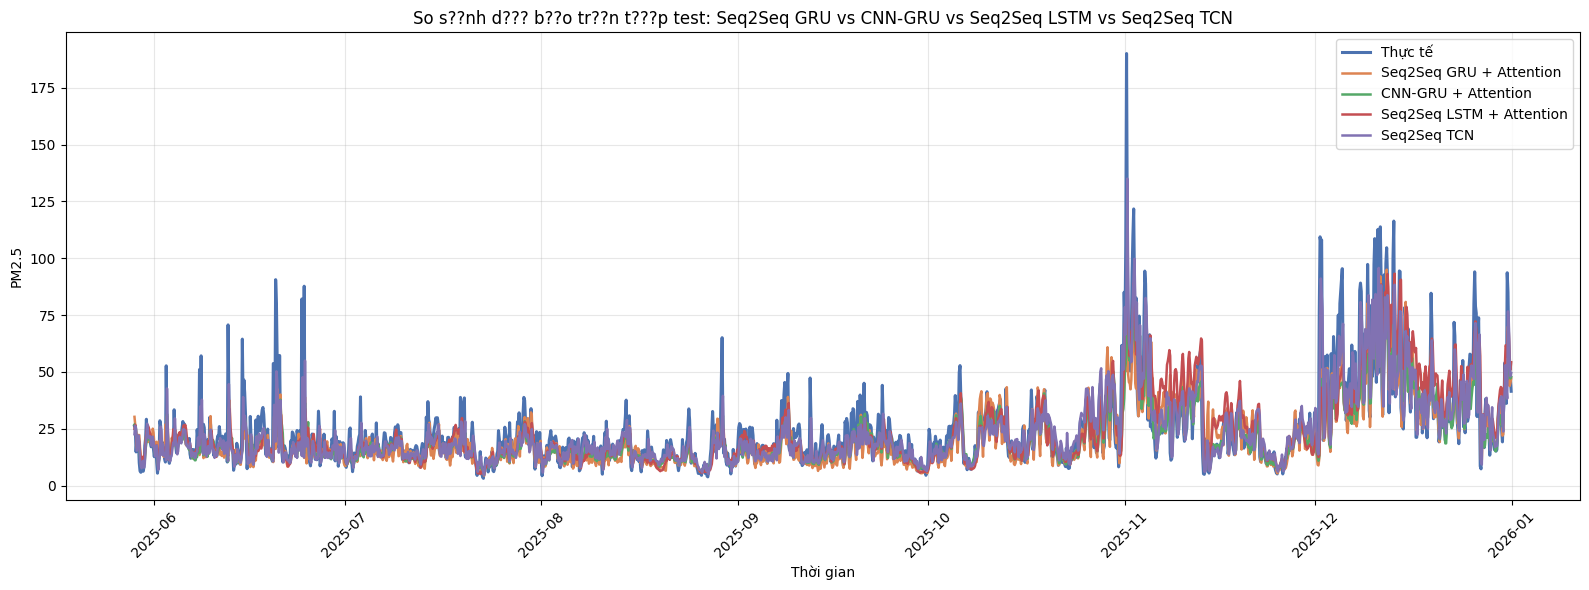

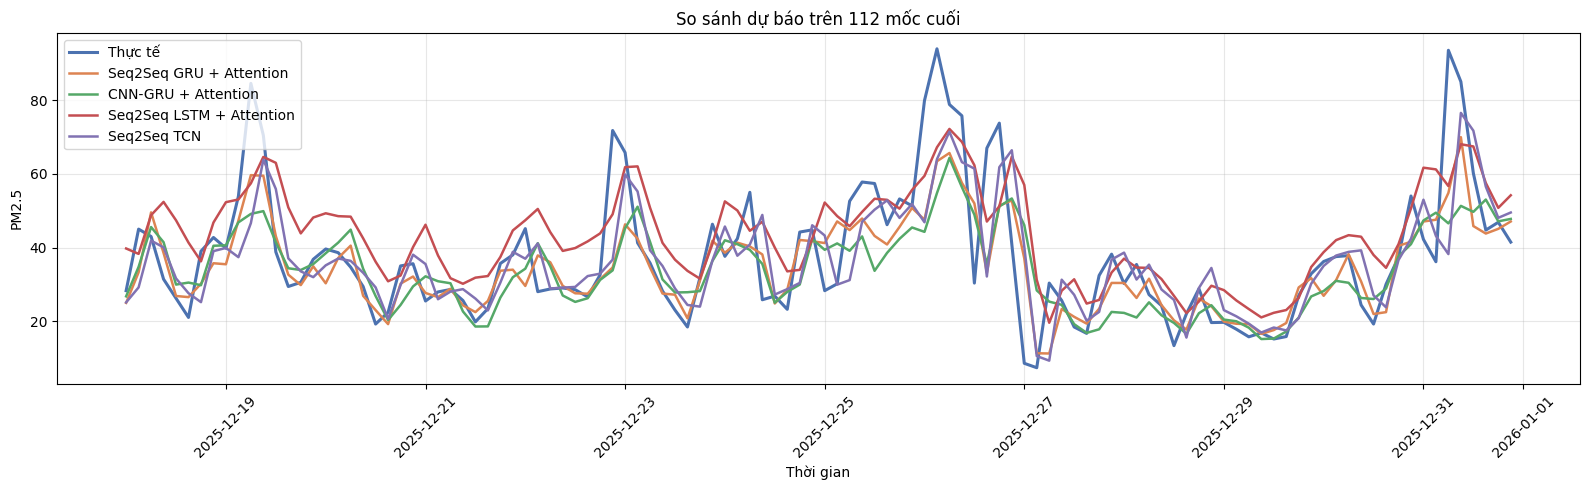

,timestamp,actual,seq_pred,cnn_pred,lstm_pred,tcn_pred
0,2025-05-28 21:00:00,26.113333,30.225813,26.824632,24.905423,22.570890
1,2025-05-29 00:00:00,25.106667,26.346980,26.369452,26.709936,26.280793
2,2025-05-29 03:00:00,14.780000,22.535917,24.280467,23.617327,25.173328
3,2025-05-29 06:00:00,19.780000,16.451515,16.278216,16.809352,15.342193
4,2025-05-29 09:00:00,21.833333,18.363345,17.090040,17.381132,20.253620
5,2025-05-29 12:00:00,19.220000,22.239668,16.977335,19.837317,22.031546
6,2025-05-29 15:00:00,10.000000,22.223532,16.691444,19.315266,19.675233
7,2025-05-29 18:00:00,6.386667,16.759869,12.151187,14.952450,11.855309
8,2025-05-29 21:00:00,5.833333,12.187026,9.510786,11.230951,8.529638
9,2025-05-30 00:00:00,8.886667,9.896597,8.912242,10.702762,7.607269


In [ ]:
# ===== So sánh: Seq2Seq GRU vs CNN-GRU vs Seq2Seq LSTM vs Seq2Seq TCN =====
required_globals = [
    "walkforward_df",
    "cnn_gru_walkforward_df",
    "test_rollout_metrics",
    "cnn_gru_test_rollout_metrics",
    "lstm_walkforward_df",
    "lstm_test_rollout_metrics",
    "tcn_walkforward_df",
    "tcn_test_rollout_metrics",
    "test_timeline_df",
    "cnn_gru_test_timeline_df",
    "lstm_test_timeline_df",
    "tcn_test_timeline_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise ValueError(f"Thiếu biến để so sánh ba mô hình: {missing_globals}")

seq_label = MODEL_LABEL if "MODEL_LABEL" in globals() else "Seq2Seq GRU + Attention"
cnn_label = CNN_GRU_MODEL_LABEL if "CNN_GRU_MODEL_LABEL" in globals() else "CNN-GRU + Attention"
lstm_label = LSTM_MODEL_LABEL if "LSTM_MODEL_LABEL" in globals() else "Seq2Seq LSTM + Attention"
tcn_label = TCN_MODEL_LABEL if "TCN_MODEL_LABEL" in globals() else "Seq2Seq TCN"

comparison_df = pd.DataFrame([
    {
        "model": seq_label,
        "val_mae": walkforward_df["rollout_mae"].mean(),
        "val_rmse": walkforward_df["rollout_rmse"].mean(),
        "val_mape": walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": test_rollout_metrics["mae"],
        "test_rmse": test_rollout_metrics["rmse"],
        "test_mape": test_rollout_metrics["mape"],
        "test_peak_mae": test_rollout_metrics["peak_mae"],
    },
    {
        "model": cnn_label,
        "val_mae": cnn_gru_walkforward_df["rollout_mae"].mean(),
        "val_rmse": cnn_gru_walkforward_df["rollout_rmse"].mean(),
        "val_mape": cnn_gru_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": cnn_gru_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": cnn_gru_test_rollout_metrics["mae"],
        "test_rmse": cnn_gru_test_rollout_metrics["rmse"],
        "test_mape": cnn_gru_test_rollout_metrics["mape"],
        "test_peak_mae": cnn_gru_test_rollout_metrics["peak_mae"],
    },
    {
        "model": lstm_label,
        "val_mae": lstm_walkforward_df["rollout_mae"].mean(),
        "val_rmse": lstm_walkforward_df["rollout_rmse"].mean(),
        "val_mape": lstm_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": lstm_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": lstm_test_rollout_metrics["mae"],
        "test_rmse": lstm_test_rollout_metrics["rmse"],
        "test_mape": lstm_test_rollout_metrics["mape"],
        "test_peak_mae": lstm_test_rollout_metrics["peak_mae"],
    },
    {
        "model": tcn_label,
        "val_mae": tcn_walkforward_df["rollout_mae"].mean(),
        "val_rmse": tcn_walkforward_df["rollout_rmse"].mean(),
        "val_mape": tcn_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": tcn_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": tcn_test_rollout_metrics["mae"],
        "test_rmse": tcn_test_rollout_metrics["rmse"],
        "test_mape": tcn_test_rollout_metrics["mape"],
        "test_peak_mae": tcn_test_rollout_metrics["peak_mae"],
    },
]).sort_values(["test_mae", "test_rmse"]).reset_index(drop=True)

print("=== Bảng so sánh ===")
display(comparison_df.round(4))

winner_row = comparison_df.iloc[0]
print(f"Mô hình tốt nhất theo test MAE: {winner_row['model']}")

seq_plot_df = test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
seq_plot_df["timestamp"] = pd.to_datetime(seq_plot_df["timestamp"])
seq_plot_df = seq_plot_df.rename(columns={"y_true": "actual", "y_pred": "seq_pred"})

cnn_plot_df = cnn_gru_test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
cnn_plot_df["timestamp"] = pd.to_datetime(cnn_plot_df["timestamp"])
cnn_plot_df = cnn_plot_df.rename(columns={"y_true": "actual_cnn", "y_pred": "cnn_pred"})

lstm_plot_df = lstm_test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
lstm_plot_df["timestamp"] = pd.to_datetime(lstm_plot_df["timestamp"])
lstm_plot_df = lstm_plot_df.rename(columns={"y_true": "actual_lstm", "y_pred": "lstm_pred"})

tcn_plot_df = tcn_test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
tcn_plot_df["timestamp"] = pd.to_datetime(tcn_plot_df["timestamp"])
tcn_plot_df = tcn_plot_df.rename(columns={"y_true": "actual_tcn", "y_pred": "tcn_pred"})

overlay_df = seq_plot_df.merge(cnn_plot_df, on="timestamp", how="inner")
overlay_df = overlay_df.merge(lstm_plot_df, on="timestamp", how="inner")
overlay_df = overlay_df.merge(tcn_plot_df, on="timestamp", how="inner")
if overlay_df.empty:
    raise ValueError("Không thể gộp dữ liệu dự báo của ba mô hình theo timestamp.")

overlay_df = overlay_df.sort_values("timestamp").reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(overlay_df["timestamp"], overlay_df["actual"], label="Thực tế", linewidth=2.2, color="#4C72B0")
plt.plot(overlay_df["timestamp"], overlay_df["seq_pred"], label=seq_label, linewidth=1.8, color="#DD8452")
plt.plot(overlay_df["timestamp"], overlay_df["cnn_pred"], label=cnn_label, linewidth=1.8, color="#55A868")
plt.plot(overlay_df["timestamp"], overlay_df["lstm_pred"], label=lstm_label, linewidth=1.8, color="#C44E52")
plt.plot(overlay_df["timestamp"], overlay_df["tcn_pred"], label=tcn_label, linewidth=1.8, color="#8172B2")
plt.title("So sánh: Seq2Seq GRU vs CNN-GRU vs Seq2Seq LSTM vs Seq2Seq TCN")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

zoom_n = min(len(overlay_df), int(14 * 24 / STEP_HOURS))
zoom_df = overlay_df.tail(zoom_n).copy()

plt.figure(figsize=(16, 5))
plt.plot(zoom_df["timestamp"], zoom_df["actual"], label="Thực tế", linewidth=2.2, color="#4C72B0")
plt.plot(zoom_df["timestamp"], zoom_df["seq_pred"], label=seq_label, linewidth=1.8, color="#DD8452")
plt.plot(zoom_df["timestamp"], zoom_df["cnn_pred"], label=cnn_label, linewidth=1.8, color="#55A868")
plt.plot(zoom_df["timestamp"], zoom_df["lstm_pred"], label=lstm_label, linewidth=1.8, color="#C44E52")
plt.plot(zoom_df["timestamp"], zoom_df["tcn_pred"], label=tcn_label, linewidth=1.8, color="#8172B2")
plt.title(f"So sánh dự báo trên {zoom_n} mốc cuối")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

overlay_df[["timestamp", "actual", "seq_pred", "cnn_pred", "lstm_pred", "tcn_pred"]].head(20)


## 16. Encoder-only Transformer


In [ ]:
# ===== Encoder-only Transformer walk-forward validation + hold-out test =====
def build_transformer_encoder_model(
    lookback,
    n_features,
    horizon,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    num_blocks=2,
    dense_units=64,
    decoder_dense_units=32,
    dropout=0.15,
    learning_rate=7e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
):
    if d_model % num_heads != 0:
        raise ValueError("d_model phải chia hết cho num_heads để đảm bảo head_dim là một số nguyên.")

    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    head_dim = max(d_model // num_heads, 1)

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="transformer_encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, 1), name="transformer_decoder_inputs")

    x = tf.keras.layers.Dense(
        d_model,
        kernel_regularizer=regularizer,
        name="transformer_input_projection",
    )(encoder_inputs)

    position_indices = tf.range(start=0, limit=lookback, delta=1)
    position_embeddings = tf.keras.layers.Embedding(
        input_dim=lookback,
        output_dim=d_model,
        name="transformer_position_embedding",
    )(position_indices)
    x = x + position_embeddings
    x = tf.keras.layers.Dropout(dropout, name="transformer_input_dropout")(x)

    for block_idx in range(1, num_blocks + 1):
        attn_input = tf.keras.layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_ln_attn_{block_idx}",
        )(x)
        attn_output = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=head_dim,
            dropout=dropout,
            kernel_regularizer=regularizer,
            name=f"transformer_mha_{block_idx}",
        )(attn_input, attn_input)
        attn_output = tf.keras.layers.Dropout(
            dropout,
            name=f"transformer_attn_dropout_{block_idx}",
        )(attn_output)
        x = tf.keras.layers.Add(name=f"transformer_attn_residual_{block_idx}")([x, attn_output])

        ffn_input = tf.keras.layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_ln_ffn_{block_idx}",
        )(x)
        ffn_output = tf.keras.layers.Dense(
            ff_dim,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name=f"transformer_ffn_expand_{block_idx}",
        )(ffn_input)
        ffn_output = tf.keras.layers.Dropout(
            dropout,
            name=f"transformer_ffn_expand_dropout_{block_idx}",
        )(ffn_output)
        ffn_output = tf.keras.layers.Dense(
            d_model,
            kernel_regularizer=regularizer,
            name=f"transformer_ffn_project_{block_idx}",
        )(ffn_output)
        ffn_output = tf.keras.layers.Dropout(
            dropout,
            name=f"transformer_ffn_project_dropout_{block_idx}",
        )(ffn_output)
        x = tf.keras.layers.Add(name=f"transformer_ffn_residual_{block_idx}")([x, ffn_output])

    x = tf.keras.layers.LayerNormalization(epsilon=1e-6, name="transformer_encoder_output_norm")(x)
    avg_context = tf.keras.layers.GlobalAveragePooling1D(name="transformer_avg_pool")(x)
    max_context = tf.keras.layers.GlobalMaxPooling1D(name="transformer_max_pool")(x)

    decoder_context = tf.keras.layers.Flatten(name="transformer_decoder_seed_flatten")(decoder_inputs)
    if decoder_dense_units:
        decoder_context = tf.keras.layers.Dense(
            decoder_dense_units,
            activation="relu",
            kernel_regularizer=regularizer,
            name="transformer_decoder_seed_dense",
        )(decoder_context)
        decoder_context = tf.keras.layers.Dropout(
            dropout,
            name="transformer_decoder_seed_dropout",
        )(decoder_context)

    x = tf.keras.layers.Concatenate(name="transformer_context_concat")(
        [avg_context, max_context, decoder_context]
    )

    if dense_units:
        x = tf.keras.layers.Dense(
            dense_units,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=regularizer,
            name="transformer_head_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="transformer_head_dropout")(x)

    outputs = tf.keras.layers.Dense(horizon, name="transformer_forecast_output")(x)

    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=outputs,
        name="encoder_only_transformer",
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


TRANSFORMER_MODEL_KWARGS = {
    "d_model": 64,
    "num_heads": 4,
    "ff_dim": 128,
    "num_blocks": 2,
    "dense_units": 64,
    "decoder_dense_units": 32,
    "dropout": 0.15,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
}
TRANSFORMER_MODEL_LABEL = "Encoder-only Transformer"
print("TRANSFORMER_MODEL_KWARGS sẵn sàng:", TRANSFORMER_MODEL_KWARGS)
print("TRANSFORMER_MODEL_LABEL:", TRANSFORMER_MODEL_LABEL)


def fit_selector_model_transformer(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = TRANSFORMER_MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence selector cho Transformer.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_transformer_encoder_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model_transformer(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = TRANSFORMER_MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history cho Transformer.")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_transformer_encoder_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant_transformer(feature_cols_local, history_feature_df, history_raw_df, future_raw_df, model_kwargs=None, selector_epochs=EPOCHS):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model_transformer(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model_transformer(
        history_X_df,
        history_y_df,
        best_epoch_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_backtest_over_full_test(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
    }


transformer_fold_rows = []
transformer_compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model_transformer(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=TRANSFORMER_MODEL_KWARGS,
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = run_assimilated_rollout(
        model=model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        chunk_metrics = chunk_metrics_df.loc[chunk_id]
        fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
        fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
        fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
        fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    transformer_compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    transformer_fold_rows.append(fold_record)

transformer_walkforward_df = pd.DataFrame(transformer_fold_rows)
print(f"=== Đánh giá walk-forward: rollout mô phỏng triển khai {ROLLOUT_HORIZON} bước = {CHUNK_HORIZON} x {N_CHUNKS} ===")
display(transformer_walkforward_df)

if not transformer_walkforward_df.empty:
    transformer_val_summary_df = pd.DataFrame([
        {
            "mean_rollout_mae": transformer_walkforward_df["rollout_mae"].mean(),
            "mean_rollout_rmse": transformer_walkforward_df["rollout_rmse"].mean(),
            "mean_chunk_1_mae": transformer_walkforward_df["chunk_1_mae"].mean(),
            "mean_chunk_2_mae": transformer_walkforward_df["chunk_2_mae"].mean() if "chunk_2_mae" in transformer_walkforward_df.columns else np.nan,
            "mean_chunk_3_mae": transformer_walkforward_df["chunk_3_mae"].mean() if "chunk_3_mae" in transformer_walkforward_df.columns else np.nan,
        }
    ])
    print()
    print("=== Tổng kết validation của Transformer ===")
    display(transformer_val_summary_df)

transformer_variant = fit_test_variant_transformer(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_backtest_raw,
    model_kwargs=TRANSFORMER_MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

transformer_best_epoch_test = transformer_variant["best_epoch"]
transformer_peak_threshold_test_train = transformer_variant["train_peak_threshold_t"]
transformer_peak_threshold_test_full = transformer_variant["train_full_peak_threshold_t"]
transformer_test_eval_summary = transformer_variant["rollout_summary"]
transformer_test_timeline_df = transformer_test_eval_summary["timeline_df"].copy()
transformer_test_chunk_metrics_df = transformer_test_eval_summary["chunk_metrics_df"].copy()
transformer_test_window_metrics_df = transformer_test_eval_summary["window_metrics_df"].copy()
transformer_test_rollout_metrics = transformer_test_eval_summary["rollout_metrics"]

transformer_test_metrics_df = pd.DataFrame([
    {
        "best_epoch": transformer_best_epoch_test,
        "test_rows": len(transformer_test_timeline_df),
        "n_backtest_windows": transformer_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "test_mae": transformer_test_rollout_metrics["mae"],
        "test_rmse": transformer_test_rollout_metrics["rmse"],
        "test_mape": transformer_test_rollout_metrics["mape"],
        "test_peak_mae": transformer_test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": transformer_peak_threshold_test_train,
        "train_val_peak_threshold_t": transformer_peak_threshold_test_full,
    }
])

transformer_test_report_df = pd.DataFrame([
    {
        "model": TRANSFORMER_MODEL_LABEL,
        "test_rows": len(transformer_test_timeline_df),
        "n_backtest_windows": transformer_test_window_metrics_df["window_id"].nunique(),
        "window_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": transformer_test_rollout_metrics["mae"],
        "rmse": transformer_test_rollout_metrics["rmse"],
        "mape": transformer_test_rollout_metrics["mape"],
        "best_epoch": transformer_best_epoch_test,
    }
])

print()
print("=== Kết quả test Transformer ===")
display(transformer_test_metrics_df)
print()
print("=== Chỉ số Transformer theo từng cửa sổ backtest ===")
display(transformer_test_window_metrics_df)
print()
print("=== Chỉ số Transformer theo từng chunk trong backtest ===")
display(transformer_test_chunk_metrics_df)
print()
print("=== Bảng tổng hợp kết quả của Transformer ===")
display(transformer_test_report_df)


## 17. So sánh giữa 5 mô hình: Seq2Seq GRU, CNN-GRU, Seq2Seq LSTM, Seq2Seq TCN va Encoder-only Transformer


In [ ]:

required_globals = [
    "walkforward_df",
    "cnn_gru_walkforward_df",
    "test_rollout_metrics",
    "cnn_gru_test_rollout_metrics",
    "lstm_walkforward_df",
    "lstm_test_rollout_metrics",
    "tcn_walkforward_df",
    "tcn_test_rollout_metrics",
    "transformer_walkforward_df",
    "transformer_test_rollout_metrics",
    "test_timeline_df",
    "cnn_gru_test_timeline_df",
    "lstm_test_timeline_df",
    "tcn_test_timeline_df",
    "transformer_test_timeline_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise ValueError(f"Thiếu biến để so sánh 5 mô hình: {missing_globals}")

seq_label = MODEL_LABEL if "MODEL_LABEL" in globals() else "Seq2Seq GRU + Attention"
cnn_label = CNN_GRU_MODEL_LABEL if "CNN_GRU_MODEL_LABEL" in globals() else "CNN-GRU + Attention"
lstm_label = LSTM_MODEL_LABEL if "LSTM_MODEL_LABEL" in globals() else "Seq2Seq LSTM + Attention"
tcn_label = TCN_MODEL_LABEL if "TCN_MODEL_LABEL" in globals() else "Seq2Seq TCN"
transformer_label = TRANSFORMER_MODEL_LABEL if "TRANSFORMER_MODEL_LABEL" in globals() else "Encoder-only Transformer"

comparison_df = pd.DataFrame([
    {
        "model": seq_label,
        "val_mae": walkforward_df["rollout_mae"].mean(),
        "val_rmse": walkforward_df["rollout_rmse"].mean(),
        "val_mape": walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": test_rollout_metrics["mae"],
        "test_rmse": test_rollout_metrics["rmse"],
        "test_mape": test_rollout_metrics["mape"],
        "test_peak_mae": test_rollout_metrics["peak_mae"],
    },
    {
        "model": cnn_label,
        "val_mae": cnn_gru_walkforward_df["rollout_mae"].mean(),
        "val_rmse": cnn_gru_walkforward_df["rollout_rmse"].mean(),
        "val_mape": cnn_gru_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": cnn_gru_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": cnn_gru_test_rollout_metrics["mae"],
        "test_rmse": cnn_gru_test_rollout_metrics["rmse"],
        "test_mape": cnn_gru_test_rollout_metrics["mape"],
        "test_peak_mae": cnn_gru_test_rollout_metrics["peak_mae"],
    },
    {
        "model": lstm_label,
        "val_mae": lstm_walkforward_df["rollout_mae"].mean(),
        "val_rmse": lstm_walkforward_df["rollout_rmse"].mean(),
        "val_mape": lstm_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": lstm_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": lstm_test_rollout_metrics["mae"],
        "test_rmse": lstm_test_rollout_metrics["rmse"],
        "test_mape": lstm_test_rollout_metrics["mape"],
        "test_peak_mae": lstm_test_rollout_metrics["peak_mae"],
    },
    {
        "model": tcn_label,
        "val_mae": tcn_walkforward_df["rollout_mae"].mean(),
        "val_rmse": tcn_walkforward_df["rollout_rmse"].mean(),
        "val_mape": tcn_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": tcn_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": tcn_test_rollout_metrics["mae"],
        "test_rmse": tcn_test_rollout_metrics["rmse"],
        "test_mape": tcn_test_rollout_metrics["mape"],
        "test_peak_mae": tcn_test_rollout_metrics["peak_mae"],
    },
    {
        "model": transformer_label,
        "val_mae": transformer_walkforward_df["rollout_mae"].mean(),
        "val_rmse": transformer_walkforward_df["rollout_rmse"].mean(),
        "val_mape": transformer_walkforward_df["rollout_mape"].mean(),
        "val_peak_mae": transformer_walkforward_df["rollout_peak_mae"].mean(),
        "test_mae": transformer_test_rollout_metrics["mae"],
        "test_rmse": transformer_test_rollout_metrics["rmse"],
        "test_mape": transformer_test_rollout_metrics["mape"],
        "test_peak_mae": transformer_test_rollout_metrics["peak_mae"],
    },
]).sort_values(["test_mae", "test_rmse"]).reset_index(drop=True)

print("=== Bảng so sánh ===")
display(comparison_df.round(4))

winner_row = comparison_df.iloc[0]
print(f"Mô hình tốt nhất theo test MAE: {winner_row['model']}")

seq_plot_df = test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
seq_plot_df["timestamp"] = pd.to_datetime(seq_plot_df["timestamp"])
seq_plot_df = seq_plot_df.rename(columns={"y_true": "actual", "y_pred": "seq_pred"})

cnn_plot_df = cnn_gru_test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
cnn_plot_df["timestamp"] = pd.to_datetime(cnn_plot_df["timestamp"])
cnn_plot_df = cnn_plot_df.rename(columns={"y_true": "actual_cnn", "y_pred": "cnn_pred"})

lstm_plot_df = lstm_test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
lstm_plot_df["timestamp"] = pd.to_datetime(lstm_plot_df["timestamp"])
lstm_plot_df = lstm_plot_df.rename(columns={"y_true": "actual_lstm", "y_pred": "lstm_pred"})

tcn_plot_df = tcn_test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
tcn_plot_df["timestamp"] = pd.to_datetime(tcn_plot_df["timestamp"])
tcn_plot_df = tcn_plot_df.rename(columns={"y_true": "actual_tcn", "y_pred": "tcn_pred"})

transformer_plot_df = transformer_test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
transformer_plot_df["timestamp"] = pd.to_datetime(transformer_plot_df["timestamp"])
transformer_plot_df = transformer_plot_df.rename(columns={"y_true": "actual_transformer", "y_pred": "transformer_pred"})

overlay_df = seq_plot_df.merge(cnn_plot_df, on="timestamp", how="inner")
overlay_df = overlay_df.merge(lstm_plot_df, on="timestamp", how="inner")
overlay_df = overlay_df.merge(tcn_plot_df, on="timestamp", how="inner")
overlay_df = overlay_df.merge(transformer_plot_df, on="timestamp", how="inner")
if overlay_df.empty:
    raise ValueError("Không thể gộp dữ liệu dự báo của 5 mô hình theo timestamp.")

overlay_df = overlay_df.sort_values("timestamp").reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(overlay_df["timestamp"], overlay_df["actual"], label="Thực tế", linewidth=2.2, color="#4C72B0")
plt.plot(overlay_df["timestamp"], overlay_df["seq_pred"], label=seq_label, linewidth=1.7, color="#DD8452")
plt.plot(overlay_df["timestamp"], overlay_df["cnn_pred"], label=cnn_label, linewidth=1.7, color="#55A868")
plt.plot(overlay_df["timestamp"], overlay_df["lstm_pred"], label=lstm_label, linewidth=1.7, color="#C44E52")
plt.plot(overlay_df["timestamp"], overlay_df["tcn_pred"], label=tcn_label, linewidth=1.7, color="#8172B2")
plt.plot(overlay_df["timestamp"], overlay_df["transformer_pred"], label=transformer_label, linewidth=1.7, color="#64B5CD")
plt.title("So sánh: GRU vs CNN-GRU vs LSTM vs TCN vs Transformer")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

zoom_n = min(len(overlay_df), int(14 * 24 / STEP_HOURS))
zoom_df = overlay_df.tail(zoom_n).copy()

plt.figure(figsize=(16, 5))
plt.plot(zoom_df["timestamp"], zoom_df["actual"], label="Thực tế", linewidth=2.2, color="#4C72B0")
plt.plot(zoom_df["timestamp"], zoom_df["seq_pred"], label=seq_label, linewidth=1.7, color="#DD8452")
plt.plot(zoom_df["timestamp"], zoom_df["cnn_pred"], label=cnn_label, linewidth=1.7, color="#55A868")
plt.plot(zoom_df["timestamp"], zoom_df["lstm_pred"], label=lstm_label, linewidth=1.7, color="#C44E52")
plt.plot(zoom_df["timestamp"], zoom_df["tcn_pred"], label=tcn_label, linewidth=1.7, color="#8172B2")
plt.plot(zoom_df["timestamp"], zoom_df["transformer_pred"], label=transformer_label, linewidth=1.7, color="#64B5CD")
plt.title(f"So sánh dự báo trên {zoom_n} mẫu cuối")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

overlay_df[["timestamp", "actual", "seq_pred", "cnn_pred", "lstm_pred", "tcn_pred", "transformer_pred"]].head(20)


In [ ]:

import matplotlib.dates as mdates

fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

models = [
    (zoom_df["seq_pred"], seq_label),
    (zoom_df["cnn_pred"], cnn_label),
    (zoom_df["lstm_pred"], lstm_label),
    (zoom_df["tcn_pred"], tcn_label),
    (zoom_df["transformer_pred"], transformer_label),
]

colors = ["#DD8452", "#55A868", "#C44E52", "#8172B2", "#64B5CD"]

for ax, (pred, label), color in zip(axes, models, colors):
    ax.plot(zoom_df["timestamp"], zoom_df["actual"],
            label="Thực tế", linewidth=2.3, color="#4C72B0")
    ax.plot(zoom_df["timestamp"], pred,
            label=label, linewidth=1.9, color=color, alpha=0.9)

    ax.set_ylabel("PM2.5")
    ax.grid(alpha=0.3, linestyle="--")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Thời gian")
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%m\n%H:%M"))

plt.xticks(rotation=0)
fig.suptitle(f"So sánh từng mô hình trên {zoom_n} mẫu cuối", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
print(test_backtest_raw.index.min(), test_backtest_raw.index.max())


In [ ]:
# FEATURE_SET_BENCHMARK_NAMES = ["production_v1", "manual_v1", "all"]
# FEATURE_SET_BENCHMARK_EPOCHS = EPOCHS

# feature_set_results = []
# for feature_set_name in FEATURE_SET_BENCHMARK_NAMES:
#     local_cols = candidate_feature_sets[feature_set_name]
#     print(f"=== Benchmark feature set: {feature_set_name} ({len(local_cols)} features) ===")
#     variant = fit_test_variant(
#         feature_cols_local=local_cols,
#         history_feature_df=train_val_feature_df,
#         history_raw_df=train_val_raw,
#         future_raw_df=test_rollout_raw,
#         model_kwargs=MODEL_KWARGS,
#         selector_epochs=FEATURE_SET_BENCHMARK_EPOCHS,
#     )

#     timeline_df = variant["rollout_summary"]["timeline_df"].copy()
#     timeline_df["timestamp"] = pd.to_datetime(timeline_df["timestamp"])
#     timeline_df["hour"] = timeline_df["timestamp"].dt.hour
#     timeline_df["dayofweek"] = timeline_df["timestamp"].dt.dayofweek
#     timeline_df["bias"] = timeline_df["y_pred"] - timeline_df["y_true"]

#     hour_profile = timeline_df.groupby("hour", as_index=False)[["y_true", "y_pred"]].mean()
#     dow_profile = timeline_df.groupby("dayofweek", as_index=False)[["y_true", "y_pred"]].mean()

#     feature_set_results.append({
#         "feature_set": feature_set_name,
#         "n_features": len(local_cols),
#         "mae": variant["rollout_summary"]["rollout_metrics"]["mae"],
#         "rmse": variant["rollout_summary"]["rollout_metrics"]["rmse"],
#         "mape": variant["rollout_summary"]["rollout_metrics"]["mape"],
#         "peak_mae": variant["rollout_summary"]["rollout_metrics"]["peak_mae"],
#         "best_epoch": variant["best_epoch"],
#         "overall_bias": timeline_df["bias"].mean(),
#         "hour_profile_mae": np.mean(np.abs(hour_profile["y_true"] - hour_profile["y_pred"])),
#         "hour_profile_corr": hour_profile[["y_true", "y_pred"]].corr().iloc[0, 1],
#         "dow_profile_mae": np.mean(np.abs(dow_profile["y_true"] - dow_profile["y_pred"])),
#         "dow_profile_corr": dow_profile[["y_true", "y_pred"]].corr().iloc[0, 1],
#     })

# feature_set_benchmark_df = pd.DataFrame(feature_set_results)
# feature_set_benchmark_df = feature_set_benchmark_df.sort_values(
#     ["mae", "rmse", "overall_bias"], ascending=[True, True, True]
# ).reset_index(drop=True)

# print("\n=== Feature-set benchmark on test rollout ===")
# display(feature_set_benchmark_df.round(3))
# print(f"Best by MAE: {feature_set_benchmark_df.loc[0, 'feature_set']}")